<a href="https://colab.research.google.com/github/Mr-Mata/house-prices-ames/blob/main/Copy_of_house_prices_eda_cells.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# What Makes a Home Worth More?
## A Real Estate Market Intelligence Analysis

**Business Context**

Buying or selling a home is one of the biggest financial decisions a person makes, yet most people have little clarity on what actually drives a property's value. Is it the size? The neighborhood? The age of the house? This analysis digs into 1,460 residential property sales in Ames, Iowa, across 80 features to answer that question with data.

Dataset is from kaggle (House Prices - Advanced Regression Techniques): https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

---

### Business Questions This Analysis Answers

1. **What property features have the strongest impact on final sale price?**
2. **How much is a 1-point increase in overall quality worth in dollars?**
3. **Is square footage or neighborhood a better predictor of price?**
4. **Do newer or recently remodeled homes command a significant price premium?**
5. **Which "invisible" features (garage, basement, fireplaces) add the most unexpected value?**

---

## A. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# Consistent visual style across all charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
})

# Brand colors used consistently throughout
PRIMARY   = '#2563EB'   # blue  : main bars / lines
SECONDARY = '#10B981'   # green : highlights / annotations
ACCENT    = '#F59E0B'   # amber : warnings / outliers
NEUTRAL   = '#6B7280'   # gray  : secondary elements

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## B. Load the Dataset

**Train dataset file**

In [ ]:
#df_raw = pd.read_csv('dataset/train.csv')
df_raw = pd.read_csv('/content/drive/MyDrive/DATABASE SYSTEMS/notebooks/House_Prices/dataset/train.csv')


print(f'Dataset shape: {df_raw.shape[0]:,} homes × {df_raw.shape[1]} features')
df_raw.head()

Dataset shape: 1,460 homes × 81 features


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df_raw.describe(include='object')

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


---

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

#### Base from the result dataset *info* the'MSSubClass' column's data type is int64 but upon checking it in the data description in kaggle it's actually category codes.

MSSubClass: Identifies the type of dwelling involved in the sale.
-   20  :    1-STORY 1946 & NEWER ALL STYLES
-   30  :   1-STORY 1945 & OLDER
-   40	:   1-STORY W/FINISHED ATTIC ALL AGES
-   50  :   1/2 STORY - UNFINISHED ALL AGES
-   50	:   1-1/2 STORY FINISHED ALL AGES
-   60	:   2-STORY 1946 & NEWER
-   70	:   2-STORY 1945 & OLDER
-   75	:   2-1/2 STORY ALL AGES
-   80	:   SPLIT OR MULTI-LEVEL
-   85  :   SPLIT FOYER
-   90	:   DUPLEX - ALL STYLES AND AGES
-   120	:   1-STORY PUD (Planned Unit Development) - 1946 & NEWER
-   150	:   1-1/2 STORY PUD - ALL AGES
-   160	:   2-STORY PUD - 1946 & NEWER
-   180 :   PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
-   190	:   2 FAMILY CONVERSION - ALL STYLES AND AGES

so fix this in data cleaning section.

---

In [ ]:
df_raw.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


**Base from the result there are 259 missing values from 'LotFrontage' column**

---

#### Full missing value map to get the complete picture of all missing values at once:

In [ ]:
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df)

              Missing Count  Missing %
PoolQC                 1453      99.52
MiscFeature            1406      96.30
Alley                  1369      93.77
Fence                  1179      80.75
MasVnrType              872      59.73
FireplaceQu             690      47.26
LotFrontage             259      17.74
GarageType               81       5.55
GarageYrBlt              81       5.55
GarageFinish             81       5.55
GarageQual               81       5.55
GarageCond               81       5.55
BsmtExposure             38       2.60
BsmtFinType2             38       2.60
BsmtQual                 37       2.53
BsmtCond                 37       2.53
BsmtFinType1             37       2.53
MasVnrArea                8       0.55
Electrical                1       0.07


#### **Base from the result:**
Most missing values does not mean they skip or forgot to input the details when they are gathering the data. This just means that the house does not really have that features like 'PoolQC' with (99.5%- means less than 1% of the dataset have a pool feature in their property),
same with
- **'MiscFeature' (96.3%)** - houses that have unique feature that are not included in the description.
- **'Alley' (93.7%)** - no alley
- **'Fence' (80.7%)** - no fence
- **'FireplaceQu' (47.3%)** - no fireplace
- **'MasVnrType'(59.7%)** and MasVnrArea(0.55%) - no masonry veneer
- **All 5 Garage columns (5.5%)** - no garage
- **All 5 Basement columns (2.5% - 2.6%)** - no basement

Only **2 Features** here shows **real missing values** that need imputation.
- **LotFrontage (17.7%)** : median (numeric, skewed)
- **Electrical (1 row)** : mode or just drop it.

---

#### **Data Type audit**

In [ ]:
print(df_raw.dtypes.value_counts())
df_raw.select_dtypes(include='object').nunique().sort_values()

object     43
int64      35
float64     3
Name: count, dtype: int64


,0
Street,2
Alley,2
Utilities,2
CentralAir,2
MasVnrType,3
LandSlope,3
PavedDrive,3
GarageFinish,3
PoolQC,3
ExterQual,4


---
## C. Data Cleaning

#### copy the raw file


In [ ]:
df = df_raw.copy()

---
### EDA Chart: Missing data audit

With 80 features, some will have gaps. Understanding *why* data is missing is as important as knowing *how much* is missing, some 'missing' values are actually informative (e.g., no `PoolQC` value means the home simply has no pool).


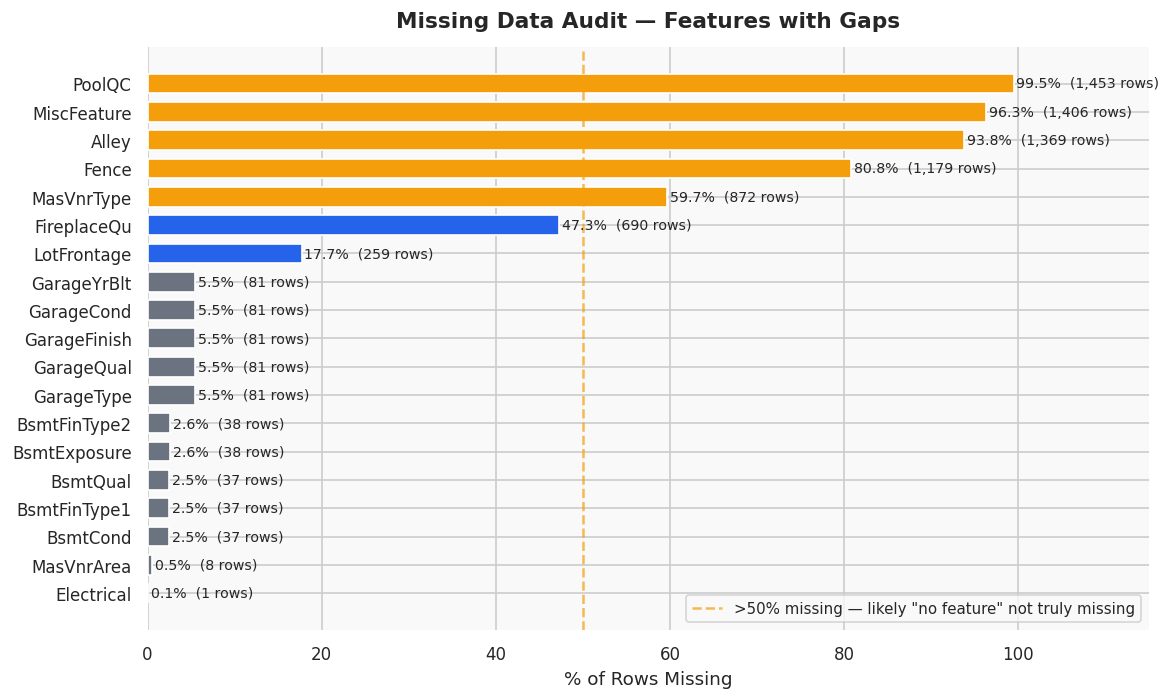

Features with >50% missing (treat as "None" — home lacks this feature):
  MasVnrType      59.7% missing — likely no masvnr on property
  Fence           80.8% missing — likely no fence on property
  Alley           93.8% missing — likely no alley on property
  MiscFeature     96.3% missing — likely no miscfeature on property
  PoolQC          99.5% missing — likely no pool on property


In [ ]:
missing = (
    df_raw.isnull().sum()
    .pipe(lambda s: s[s > 0])
    .sort_values(ascending=True)
)
missing_pct = (missing / len(df_raw) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))

colors = [ACCENT if pct > 50 else (PRIMARY if pct > 15 else NEUTRAL)
          for pct in missing_pct.values]
bars = ax.barh(missing.index, missing_pct.values, color=colors,
               edgecolor='white', height=0.7)

for bar, pct, cnt in zip(bars, missing_pct.values, missing.values):
    ax.text(pct + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct}%  ({cnt:,} rows)', va='center', fontsize=8.5)

ax.axvline(50, color=ACCENT, linewidth=1.5, linestyle='--', alpha=0.7,
           label='>50% missing — likely "no feature" not truly missing')
ax.set_xlim(0, 115)
ax.set_xlabel('% of Rows Missing')
ax.set_title('Missing Data Audit — Features with Gaps', pad=12)
ax.legend(fontsize=9)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

print('Features with >50% missing (treat as "None" — home lacks this feature):')
for feat, pct in missing_pct[missing_pct > 50].items():
    print(f'  {feat:<15} {pct}% missing — likely no {feat.replace("QC","").replace("Type","").lower()} on property')

**What this tells us:** Features like `PoolQC`, `MiscFeature`, `Alley`, and `Fence` are missing for 80%+ of homes, not because of data collection errors, but because most homes simply don't have a pool, alley access, or special fence. We treat these as a `'None'` category, not as gaps to fill with averages. Features like `LotFrontage` (18% missing) require proper median imputation.

### 1. Fill with 'None' or '0' the 'No Feature' nulls

In [ ]:
# Impute Categorical features, missing means the simply does not have this feature
none_fill_cat = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence',
    'FireplaceQu',
    'MasVnrType',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
]
df[none_fill_cat] = df[none_fill_cat].fillna('None')

In [ ]:
# Numeric features, missing means 0 (for example: no garage = 0 year built, no veneer = 0 area)
zero_fill_num = ['MasVnrArea', 'GarageYrBlt']
df[zero_fill_num] = df[zero_fill_num].fillna(0)

### 2. Imputer Real Missing Values

In [ ]:
# LotFrontage column: use median per neighborhood rather than global median
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

#### using global media would be too blunt, and A home in a dense neighborhood likely has a smaller frontage than one in suburb area. so by grouping 'LotFrontage' with 'Neighborhood' before taking the median gives a much more realistic imputation.

In [ ]:
#Electical: only 1 row missing so fill with mode
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

### 3. Fix fake numeric column

In [ ]:
# Change 'MSSubClass' column data type to string
df['MSSubClass'] = df['MSSubClass'].astype(str)

### 4. Drop "Id' its a row index and not a feature.

In [ ]:
df = df.drop(columns=['Id'])

### Verify null cleaning

In [ ]:
print("Remaining Nulls: ", df.isnull().sum().sum())
print("Shape after Cleaning: ", df.shape)
df.head()

Remaining Nulls:  0
Shape after Cleaning:  (1460, 80)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,0,None,None,None,0,12,2008,WD,Normal,250000


In [ ]:
df

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,None,None,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,...,0,None,None,None,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,...,0,None,None,None,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,...,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,...,0,None,None,None,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,RL,62.0,7917,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,None,None,0,8,2007,WD,Normal,175000
1456,20,RL,85.0,13175,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,MnPrv,None,0,2,2010,WD,Normal,210000
1457,70,RL,66.0,9042,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,20,RL,68.0,9717,Pave,None,Reg,Lvl,AllPub,Inside,...,0,None,None,None,0,4,2010,WD,Normal,142125


---
## D. Feature Engineering

There are a lot  to fix in the dataset features like we can combined related columns into one stronger signal, Convert or encode the categorical text into numbers for model to read and understand it.


### 1. Size Combination

In [ ]:
df['TotalSF'] = (df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF'])
                        #basement       #groundflr      upperfloor (0 if single-story house)

In [ ]:
df['TotalBath'] = (df['FullBath'] + df['BsmtFullBath'] + df['HalfBath'] * 0.5 + df['BsmtHalfBath'] * 0.5 )

In [ ]:
df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'])

In [ ]:
# Ratio: how much of the total area is actually livable above ground?
# Low ratio = big basement relative to house (could mean unfinished space)
df['LivingAreaRatio'] = df['GrLivArea'] / df['TotalSF'].replace(0, 1)

### 2. Age and Time Features

In [ ]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']
# House Age will tell that 'this house is 40 yrs old', in this way it is very much cleaner signal for the model rathwr thna raw years  like 1950, 2003 etc..

In [ ]:
# Binary flags: so yes or no question
df['WasRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
df['IsNewHome'] = (df['YrSold'] == df['YearBuilt']).astype(int)

# negative ages can appear from data entry errors, so we need to check it
neg_age = df[df['HouseAge'] < 0]
if len(neg_age) > 0:
    print(f" Error: {len(neg_age)} rows have negative HouseAge - Cliping to 0")
    df['HouseAge'] = df['HouseAge'].clip(lower=0)
    df['YearsSinceRemodel'] = df['YearsSinceRemodel'].clip(lower=0)


### 3. Ordinal Encoding

There are columns that have a ranking like (Poor < Fair < Avarage < Good < Excellent) but the thing is they are stored as strings. we need to encode them to **0-5** so the model can undestands order. If we do not do this columns that have categorical values like 'Ex' and 'po' will look like two random unrelated categories and therefore can't be read by the model.

In [ ]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

ordinal_quality_cols = [
    'ExterQual',    # exterior material quality
    'ExterCond',    # exterior condition
    'BsmtQual',     # basement height quality
    'BsmtCond',     # basement condition
    'HeatingQC',    # heating quality
    'KitchenQual',  # kitchen quality
    'FireplaceQu',  # fireplace quality (None = no fireplace)
    'GarageQual',   # garage quality   (None = no garage)
    'GarageCond',   # garage condition (None = no garage)
    'PoolQC',       # pool quality     (None = no pool)
]

for col in ordinal_quality_cols:
    df[col] = df[col].map(quality_map)

In [ ]:
# BsmtExposure has its own scale (not the Ex/Gd/TA/Fa/Po scale)
df['BsmtExposure'] = df['BsmtExposure'].map(
    {'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
)

In [ ]:
# Garage finish has its own scale too
df['GarageFinish'] = df['GarageFinish'].map(
    {'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
)

In [ ]:
# PavedDrive: dirt < partial < fully paved
df['PavedDrive'] = df['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2})

In [ ]:
# LotShape: regular is best, irregular is worst
df['LotShape'] = df['LotShape'].map(
    {'IR3': 0, 'IR2': 1, 'IR1': 2, 'Reg': 3}
)

In [ ]:
# LandSlope: gentle is most desirable
df['LandSlope'] = df['LandSlope'].map({'Sev': 0, 'Mod': 1, 'Gtl': 2})

In [ ]:
# Functional: Typ is best, Sal is worst — reversed scale
functional_map = {
    'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3,
    'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7
}
df['Functional'] = df['Functional'].map(functional_map)

In [ ]:
# Basement finish type — quality of finished basement area
bsmt_fin_map = {
    'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3,
    'BLQ': 4, 'ALQ': 5, 'GLQ': 6
}
df['BsmtFinType1'] = df['BsmtFinType1'].map(bsmt_fin_map)
df['BsmtFinType2'] = df['BsmtFinType2'].map(bsmt_fin_map)

### 4. Boolean Presence / Absence Flags

Simple yes or no, 'does this home have this feature at all?

These are often stronger signals than the raw area/count columns.

In [ ]:
df['HasPool']      = (df['PoolArea']    > 0).astype(int)
df['HasGarage']    = (df['GarageArea']  > 0).astype(int)
df['HasBasement']  = (df['TotalBsmtSF'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces']  > 0).astype(int)
df['Has2ndFloor']  = (df['2ndFlrSF']   > 0).astype(int)
df['HasDeck']      = (df['WoodDeckSF']  > 0).astype(int)
df['HasPorch']     = (df['TotalPorchSF']> 0).astype(int)

### Verify engineered features

In [ ]:
new_features = [
    'TotalSF', 'TotalBath', 'TotalPorchSF', 'LivingAreaRatio',
    'HouseAge', 'YearsSinceRemodel', 'WasRemodeled', 'IsNewHome',
    'HasPool', 'HasGarage', 'HasBasement', 'HasFireplace',
    'Has2ndFloor', 'HasDeck', 'HasPorch'
]

print("── New features created ──────────────────────────────────────────")
print(df[new_features].describe().round(2))
print(f"\nDataset shape after feature engineering: {df.shape}")
print(f"New column count: {df.shape[1]} (was 80 after cleaning)")
print(f"\nAny new nulls introduced? {df[new_features].isnull().sum().sum()}")

── New features created ──────────────────────────────────────────
        TotalSF  TotalBath  TotalPorchSF  LivingAreaRatio  HouseAge  \
count   1460.00    1460.00       1460.00          1460.00   1460.00   
mean    2567.05       2.21         87.08             0.59     36.55   
std      821.71       0.79        105.19             0.11     30.25   
min      334.00       1.00          0.00             0.34      0.00   
25%     2009.50       2.00          0.00             0.50      8.00   
50%     2474.00       2.00         48.00             0.56     35.00   
75%     3004.00       2.50        136.00             0.67     54.00   
max    11752.00       6.00       1027.00             1.02    136.00   

       YearsSinceRemodel  WasRemodeled  IsNewHome  HasPool  HasGarage  \
count            1460.00       1460.00    1460.00  1460.00    1460.00   
mean               22.95          0.48       0.04     0.00       0.94   
std                20.64          0.50       0.20     0.07       0.23   
m

In [ ]:
# Check which of the expected features actually exist in df
expected = [
    'TotalSF', 'TotalBath', 'TotalPorchSF', 'LivingAreaRatio',
    'HouseAge', 'YearsSinceRemodel', 'WasRemodeled', 'IsNewHome',
    'HasPool', 'HasGarage', 'HasBasement', 'HasFireplace',
    'Has2ndFloor', 'HasDeck', 'HasPorch'
]

missing_features = [f for f in expected if f not in df.columns]
present_features = [f for f in expected if f in df.columns]

print(" Created successfully:", present_features)
print(" Missing:", missing_features)

 Created successfully: ['TotalSF', 'TotalBath', 'TotalPorchSF', 'LivingAreaRatio', 'HouseAge', 'YearsSinceRemodel', 'WasRemodeled', 'IsNewHome', 'HasPool', 'HasGarage', 'HasBasement', 'HasFireplace', 'Has2ndFloor', 'HasDeck', 'HasPorch']
 Missing: []


---
### Exporting the cleaned dataframe for Viz on other apps

In [ ]:
df.to_csv('house_prices_cleaned.csv', index=False)

---
## E. Exploratory Data Analysis

Before building any model, we need to understand the data — its shape, its outliers, and the stories it tells. Every chart in this section is designed to answer one of the five business questions.

---
### EDA Chart 1 — How are home prices distributed?

Understanding the spread of sale prices is the foundation of any real estate analysis. A right-skewed distribution (many mid-range homes, few luxury outliers) requires log transformation before modeling to avoid bias.

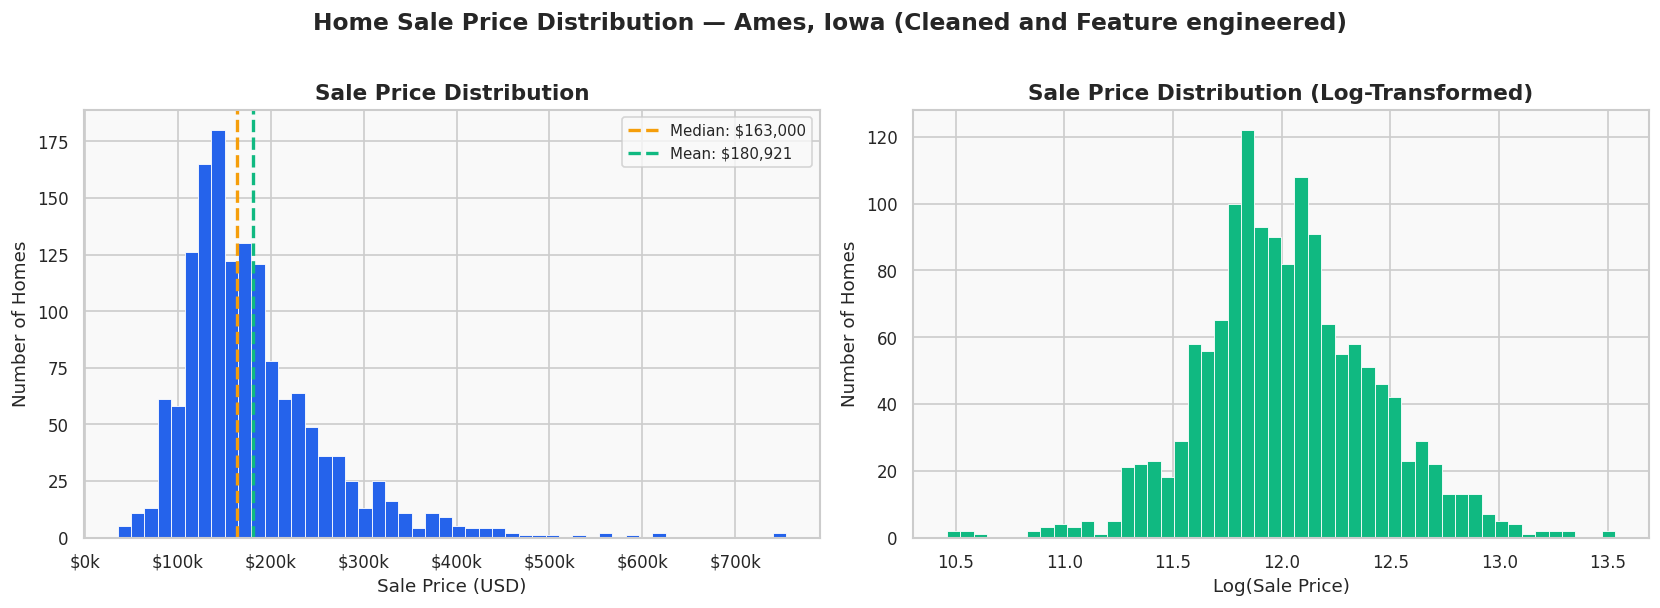

  Minimum sale price : $    34,900
  Maximum sale price : $   755,000
  Median sale price  : $   163,000
  Mean sale price    : $   180,921
  Skewness           :       1.88


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#  Left: Cleaned and engineered price distribution=============================
axes[0].hist(df['SalePrice'], bins=50, color=PRIMARY, edgecolor='white', linewidth=0.5)
axes[0].axvline(df['SalePrice'].median(), color=ACCENT, linewidth=2,
                linestyle='--', label=f"Median: ${df['SalePrice'].median():,.0f}")
axes[0].axvline(df['SalePrice'].mean(), color=SECONDARY, linewidth=2,
                linestyle='--', label=f"Mean: ${df['SalePrice'].mean():,.0f}")
axes[0].set_title('Sale Price Distribution')
axes[0].set_xlabel('Sale Price (USD)')
axes[0].set_ylabel('Number of Homes')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend(fontsize=9)

# Right: log-transformed ======================================================
log_price = np.log1p(df['SalePrice'])
axes[1].hist(log_price, bins=50, color=SECONDARY, edgecolor='white', linewidth=0.5)
axes[1].set_title('Sale Price Distribution (Log-Transformed)')
axes[1].set_xlabel('Log(Sale Price)')
axes[1].set_ylabel('Number of Homes')

plt.suptitle('Home Sale Price Distribution — Ames, Iowa (Cleaned and Feature engineered)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"  Minimum sale price : ${df['SalePrice'].min():>10,.0f}")
print(f"  Maximum sale price : ${df['SalePrice'].max():>10,.0f}")
print(f"  Median sale price  : ${df['SalePrice'].median():>10,.0f}")
print(f"  Mean sale price    : ${df['SalePrice'].mean():>10,.0f}")
print(f"  Skewness           : {df['SalePrice'].skew():>10.2f}")

**What this tells us:** The raw distribution is right-skewed, most homes sold between \$100k–\$250k, but a small number of luxury properties pull the average upward. The log-transformed version closely resembles a normal bell curve, which is why we apply log transformation before regression modeling. For a buyer, this confirms that the \"typical\" home in Ames is well under \$200k.

---
### EDA Chart 2: Which features correlate most with sale price? (Using the raw and cleaned & engineered dataset)

Out of 80 features, which ones actually moves the needle on the price? This chart ranks the top 15 numerical features by their correlation with SalePrice, giving us a data-driven shortlist of what matters the most.

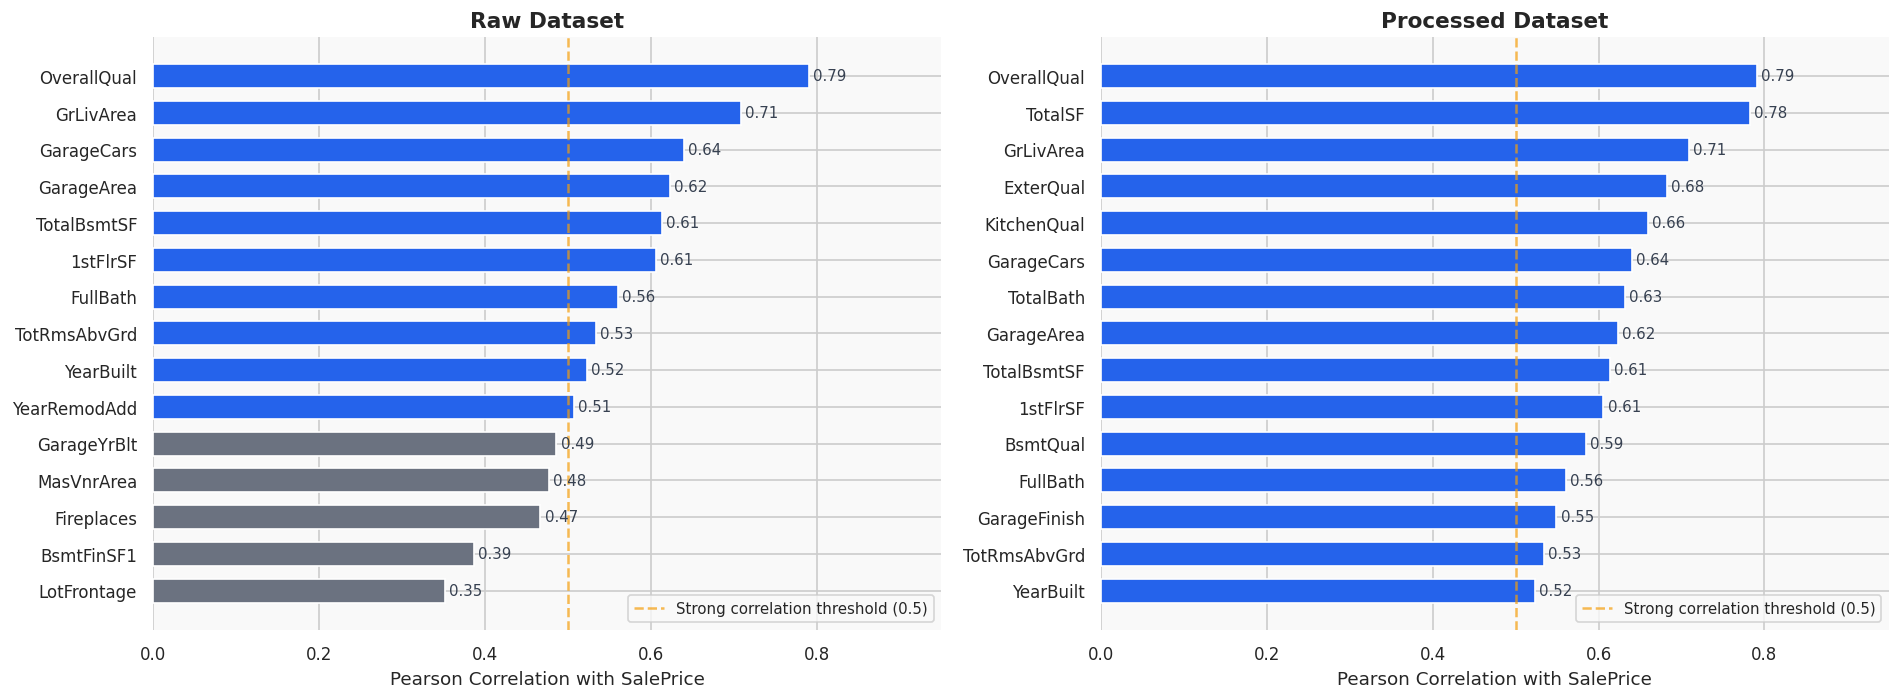


RAW DATASET:
  OverallQual          0.791
  GrLivArea            0.709
  GarageCars           0.640
  GarageArea           0.623
  TotalBsmtSF          0.614
  1stFlrSF             0.606
  FullBath             0.561
  TotRmsAbvGrd         0.534
  YearBuilt            0.523
  YearRemodAdd         0.507

CLEANED DATASET:
  OverallQual          0.791
  TotalSF              0.782
  GrLivArea            0.709
  ExterQual            0.683
  KitchenQual          0.660
  GarageCars           0.640
  TotalBath            0.632
  GarageArea           0.623
  TotalBsmtSF          0.614
  1stFlrSF             0.606
  BsmtQual             0.585
  FullBath             0.561
  GarageFinish         0.549
  TotRmsAbvGrd         0.534
  YearBuilt            0.523
  FireplaceQu          0.520
  YearRemodAdd         0.507


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# =========================
# For RAW dataset
# =========================
num_cols_raw = df_raw.select_dtypes(include='number').columns

corr_raw = (
    df_raw[num_cols_raw]
    .corr()['SalePrice']
    .drop('SalePrice')
    .sort_values(ascending=False)
)

top15_raw = corr_raw.head(15)

colors = [PRIMARY if v >= 0.5 else NEUTRAL for v in top15_raw.values]

bars = ax[0].barh(
    top15_raw.index[::-1],
    top15_raw.values[::-1],
    color=colors[::-1],
    edgecolor='white',
    height=0.65
)

for bar, val in zip(bars, top15_raw.values[::-1]):
    ax[0].text( val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
        va='center', fontsize=9, color='#374151')

ax[0].axvline(
    0.5,
    color=ACCENT,
    linewidth=1.5,
    linestyle='--',
    alpha=0.7,
    label='Strong correlation threshold (0.5)'
)

ax[0].set_xlim(0, 0.95)
ax[0].set_xlabel('Pearson Correlation with SalePrice')
ax[0].set_title('Raw Dataset')
ax[0].legend(fontsize=9)

# =========================
# For CLEANED & ENGINEERED DATASET
# =========================
num_cols = df.select_dtypes(include='number').columns

corr = (
    df[num_cols]
    .corr()['SalePrice']
    .drop('SalePrice')
    .sort_values(ascending=False)
)

top15 = corr.head(15)

colors = [PRIMARY if v >= 0.5 else NEUTRAL for v in top15.values]

bars = ax[1].barh(
    top15.index[::-1],
    top15.values[::-1],
    color=colors[::-1],
    edgecolor='white',
    height=0.65
)

for bar, val in zip(bars, top15.values[::-1]):
    ax[1].text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
        va='center',fontsize=9, color='#374151')

ax[1].axvline(
    0.5,
    color=ACCENT,
    linewidth=1.5,
    linestyle='--',
    alpha=0.7,
    label='Strong correlation threshold (0.5)'
)

ax[1].set_xlim(0, 0.95)
ax[1].set_xlabel('Pearson Correlation with SalePrice')
ax[1].set_title('Processed Dataset')
ax[1].legend(fontsize=9)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

# =========================
# PRINT STRONG FEATURES
# =========================
print('\nRAW DATASET:')
strong_raw = corr_raw[corr_raw > 0.5]

for feat, val in strong_raw.items():
    print(f'  {feat:<20} {val:.3f}')

print('\nCLEANED DATASET:')
strong = corr[corr > 0.5]

for feat, val in strong.items():
    print(f'  {feat:<20} {val:.3f}')

**What this tells us:** The top price drivers are `OverallQual` (quality rating), `GrLivArea` (above-ground living area), and garage/basement features. Notably, `OverallQual` has a correlation of ~0.79 — the strongest single predictor in the dataset. This means **quality of finish matters more than size** when it comes to determining a home's market value.

Interpretation of Correlation Analysis

The strongest predictors of SalePrice are dominated by overall **construction quality, living space, and functional home features.**

In the *raw dataset*, the top correlated variables are:

- `OverallQual` (0.791)
- `GrLivArea` (0.709)
- `GarageCars` (0.640)
- `GarageArea` (0.623)
- `TotalBsmtSF` (0.614)

This indicates that buyers value a combination of:

**construction/finish quality,
usable living area,
garage capacity,
and basement size.**

After feature engineering and preprocessing, several newly created or encoded features became highly predictive:

- `TotalSF` (0.782)
- `ExterQual` (0.683)
- `KitchenQual` (0.660)
- `TotalBath` (0.632)
- `BsmtQual` (0.585)
- `GarageFinish` (0.549)
- `FireplaceQu` (0.520)

This shows that transforming qualitative attributes into ordinal numeric representations successfully captured important information about perceived home value.

A particularly important insight is that `OverallQual` remains the strongest single predictor with a correlation of approximately **0.79** in both datasets. This suggests that overall construction and finish quality has a greater influence on housing prices than sheer size alone. Although `GrLivArea` is also strongly correlated **(0.709)**, buyers appear willing to pay a premium for higher-quality homes even when they are not the largest properties.

---
### EDA Chart 3: The quality premium: how much is each quality tier worth?

Overall quality is rated 1–10 in this dataset. This chart reveals the dollar premium associated with each quality tier, directly answering: *'If I upgrade my home's finish quality, how much more can I ask for?'*

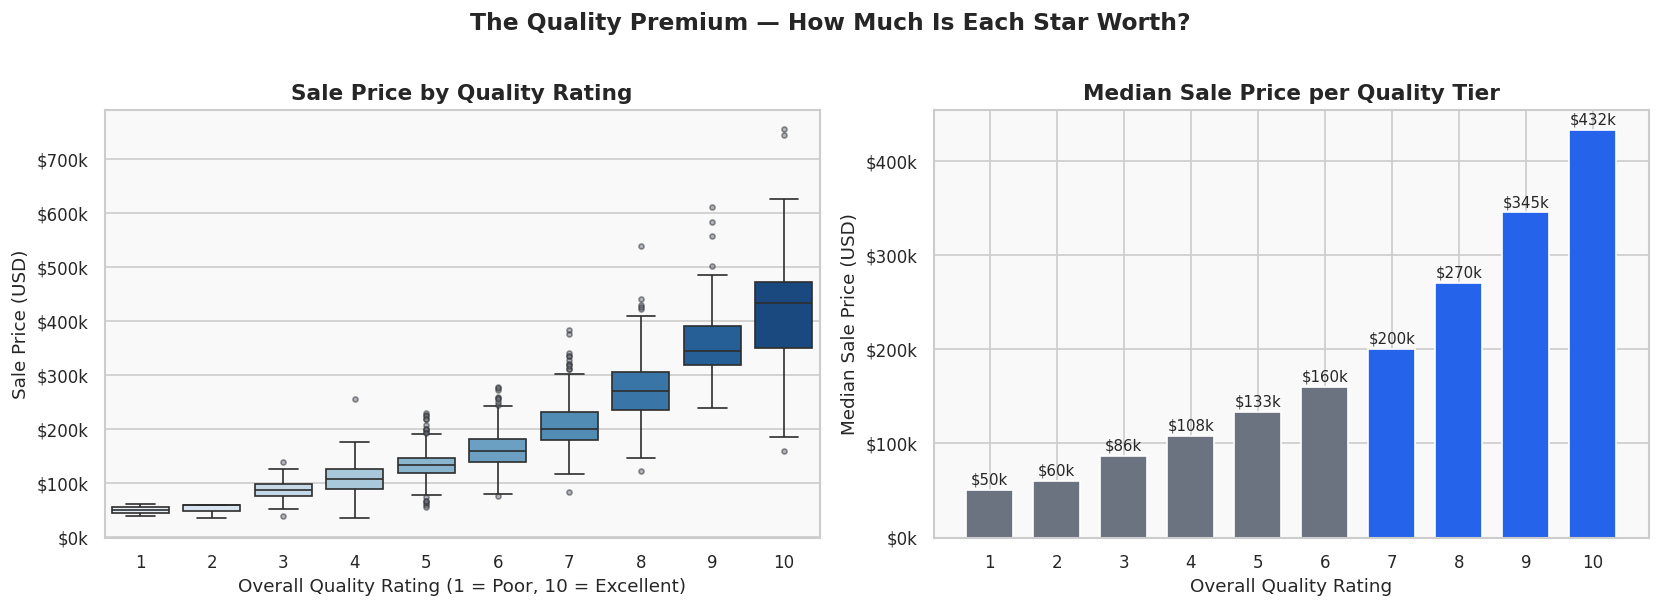

Dollar value of moving up one quality tier:
  Quality 1 → 2: +$9,850
  Quality 2 → 3: +$26,250
  Quality 3 → 4: +$21,750
  Quality 4 → 5: +$25,000
  Quality 5 → 6: +$27,000
  Quality 6 → 7: +$40,141
  Quality 7 → 8: +$69,609
  Quality 8 → 9: +$75,250
  Quality 9 → 10: +$87,390


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: boxplot of price by quality tier========================================
qual_order = sorted(df['OverallQual'].unique())
qual_palette = sns.color_palette('Blues', n_colors=len(qual_order))

sns.boxplot(
    data=df, x='OverallQual', y='SalePrice',
    order=qual_order, palette=qual_palette, ax=axes[0],
    flierprops=dict(marker='o', markerfacecolor=NEUTRAL, markersize=3, alpha=0.5)
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].set_xlabel('Overall Quality Rating (1 = Poor, 10 = Excellent)')
axes[0].set_ylabel('Sale Price (USD)')
axes[0].set_title('Sale Price by Quality Rating')

# Right: median price per quality tier as bar chart==============================
median_by_qual = df.groupby('OverallQual')['SalePrice'].median().reset_index()
bars = axes[1].bar(
    median_by_qual['OverallQual'],
    median_by_qual['SalePrice'],
    color=[PRIMARY if q >= 7 else NEUTRAL for q in median_by_qual['OverallQual']],
    edgecolor='white', width=0.7
)
for bar, val in zip(bars, median_by_qual['SalePrice']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
                 f'${val/1000:.0f}k', ha='center', va='bottom', fontsize=9)

axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].set_xlabel('Overall Quality Rating')
axes[1].set_ylabel('Median Sale Price (USD)')
axes[1].set_title('Median Sale Price per Quality Tier')
axes[1].set_xticks(qual_order)

plt.suptitle('The Quality Premium — How Much Is Each Star Worth?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Dollar difference between adjacent quality tiers
print('Dollar value of moving up one quality tier:')
median_by_qual = df.groupby('OverallQual')['SalePrice'].median()
for q in range(2, 11):
    if q in median_by_qual.index and (q-1) in median_by_qual.index:
        diff = median_by_qual[q] - median_by_qual[q-1]
        print(f'  Quality {q-1} → {q}: +${diff:,.0f}')

**What this tells us:** Moving from quality tier 5 to 6 adds roughly \$20,000 in median value. Moving from tier 7 to 8 can add \$50,000+. The premium accelerates at the top end of the scale, luxury finishes yield disproportionately higher returns.

**For sellers:** targeted quality upgrades (kitchen remodels, flooring, fixtures) before listing can yield a significant return on investment.

---
### EDA Chart 4: Neighborhood price comparison

Where a home sits in the city often matters as much as the home itself. This chart ranks all neighborhoods by median sale price, the most immediately useful insight for buyers trying to find value.

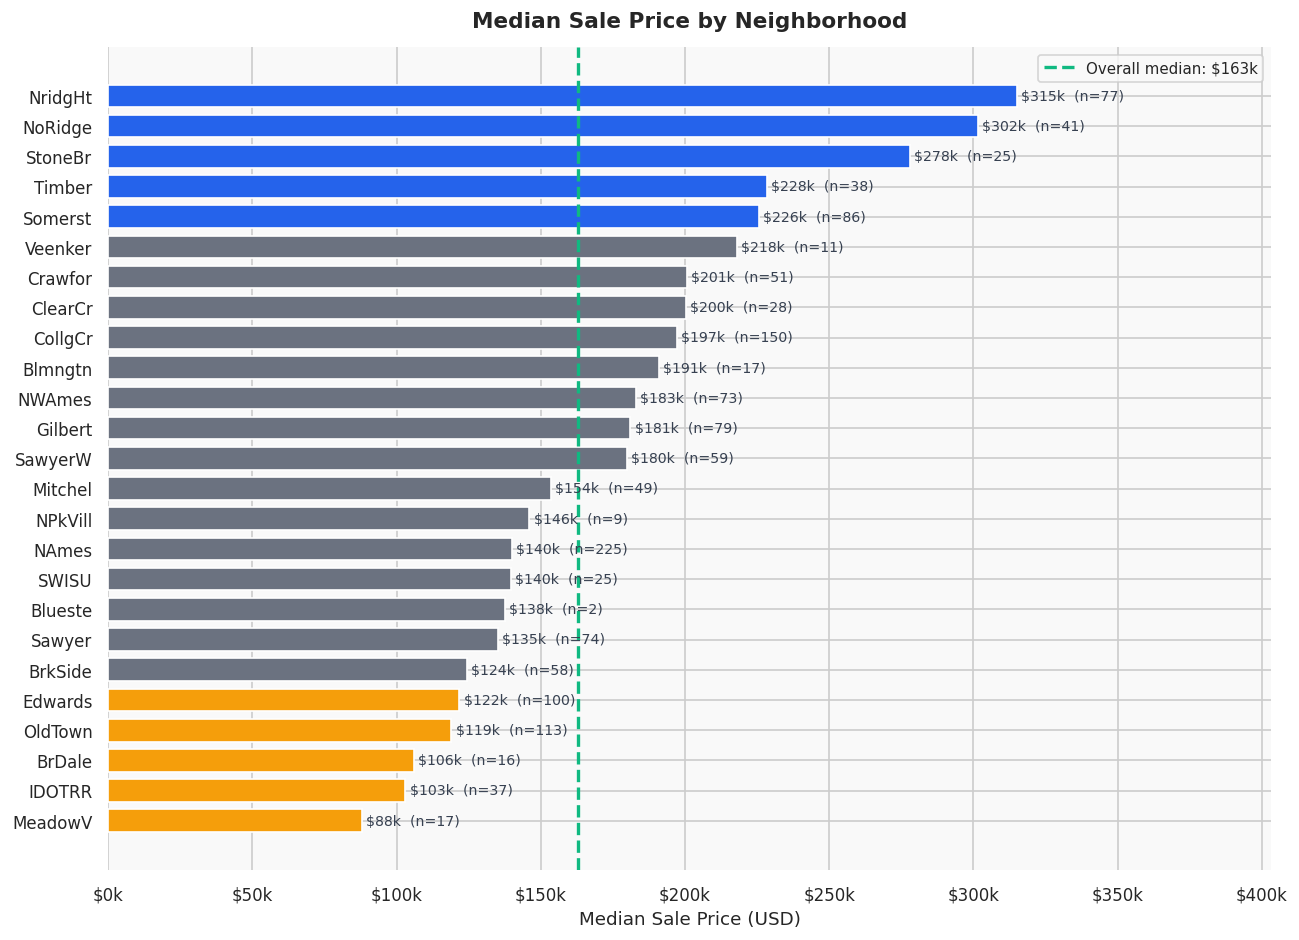

Most expensive neighborhood : NridgHt — median $315,000
Most affordable neighborhood: MeadowV — median $88,000
Price gap between top & bottom: $227,000


In [ ]:
#------------------------------------------------------------------------------------------------
neighborhood_stats = (
    df.groupby('Neighborhood')['SalePrice']
    .agg(median_price='median', count='count', std_price='std')
    .sort_values('median_price', ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 8))

# Color top 5 and bottom 5 differently
n = len(neighborhood_stats)
bar_colors = (
    [ACCENT] * 5 +
    [NEUTRAL] * (n - 10) +
    [PRIMARY] * 5
)

bars = ax.barh(
    neighborhood_stats['Neighborhood'],
    neighborhood_stats['median_price'],
    color=bar_colors, edgecolor='white', height=0.75
)

# Value labels
for bar, val, cnt in zip(bars, neighborhood_stats['median_price'],
                          neighborhood_stats['count']):
    ax.text(val + 1500, bar.get_y() + bar.get_height()/2,
            f'${val/1000:.0f}k  (n={cnt})',
            va='center', ha='left', fontsize=8.5, color='#374151')

overall_median = df['SalePrice'].median()
ax.axvline(overall_median, color=SECONDARY, linewidth=2, linestyle='--',
           label=f'Overall median: ${overall_median/1000:.0f}k')

ax.set_xlim(0, neighborhood_stats['median_price'].max() * 1.28)
ax.set_xlabel('Median Sale Price (USD)')
ax.set_title('Median Sale Price by Neighborhood', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.legend(fontsize=9)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

top_hood = neighborhood_stats.iloc[-1]
bot_hood = neighborhood_stats.iloc[0]
print(f'Most expensive neighborhood : {top_hood["Neighborhood"]} — median ${top_hood["median_price"]:,.0f}')
print(f'Most affordable neighborhood: {bot_hood["Neighborhood"]} — median ${bot_hood["median_price"]:,.0f}')
print(f'Price gap between top & bottom: ${top_hood["median_price"] - bot_hood["median_price"]:,.0f}')

**What this tells us:** There is a dramatic price gap between Ames neighborhoods, the most expensive area commands nearly 4× the median price of the most affordable one. For **buyers**, neighborhoods sitting just below the overall median line (the green dashed line) represent potential value, similar amenities at a lower price point. For **agents**, this chart is a quick-reference benchmarking tool.

---
### EDA Chart 5 — Size vs. price: when does more space stop paying off?

Above-ground living area (`GrLivArea`) is the second strongest predictor of price. But is the relationship perfectly linear? This chart shows where diminishing returns begin, and flags extreme outliers that could distort our model.

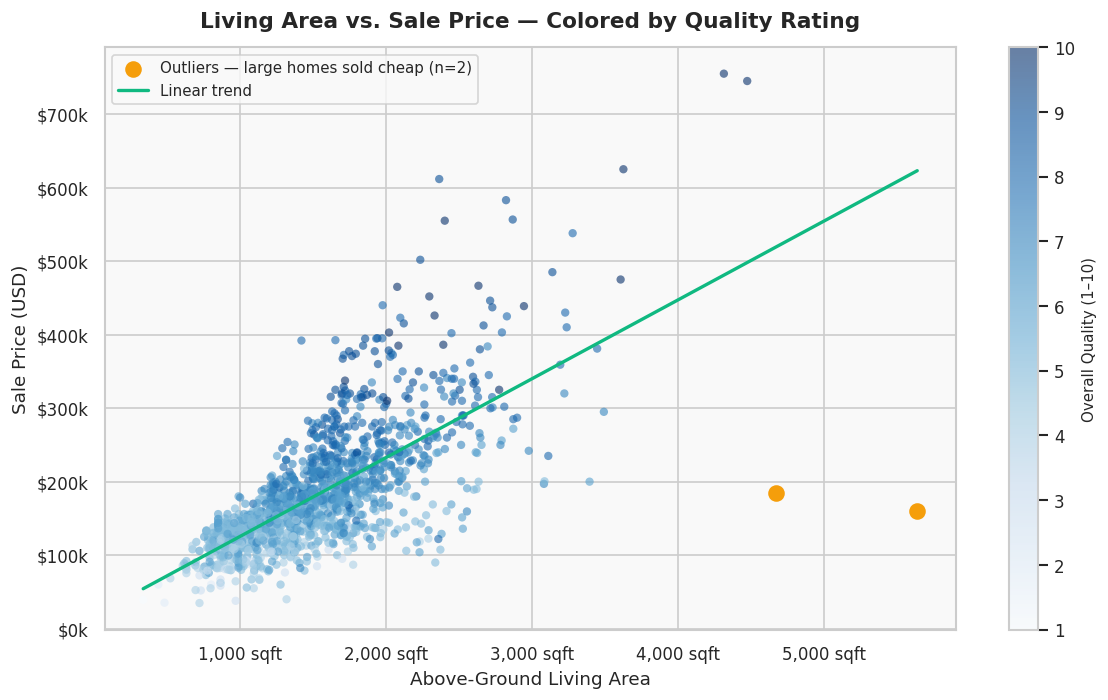

Average price per sq ft: $121
Median price per sq ft:  $120
Number of outlier homes flagged: 2


In [ ]:
#----------------
fig, ax = plt.subplots(figsize=(10, 6))

# Color-code by quality tier for a 3-variable story in one chart
qual_cmap = plt.cm.Blues
scatter = ax.scatter(
    df['GrLivArea'], df['SalePrice'],
    c=df['OverallQual'], cmap='Blues',
    alpha=0.6, s=25, edgecolors='none'
)

# Highlight the well-known outliers (large area, low price)
outliers = df[(df['GrLivArea'] > 4000) & (df_raw['SalePrice'] < 200000)]
ax.scatter(outliers['GrLivArea'], outliers['SalePrice'],
           color=ACCENT, s=80, zorder=5,
           label=f'Outliers — large homes sold cheap (n={len(outliers)})')

# Trend line
m, b = np.polyfit(df_raw['GrLivArea'], df_raw['SalePrice'], 1)
x_line = np.linspace(df_raw['GrLivArea'].min(), df_raw['GrLivArea'].max(), 200)
ax.plot(x_line, m * x_line + b, color=SECONDARY, linewidth=2, label='Linear trend')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Overall Quality (1–10)', fontsize=9)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} sqft'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_xlabel('Above-Ground Living Area')
ax.set_ylabel('Sale Price (USD)')
ax.set_title('Living Area vs. Sale Price — Colored by Quality Rating', pad=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

price_per_sqft = df['SalePrice'] / df['GrLivArea']
print(f'Average price per sq ft: ${price_per_sqft.mean():,.0f}')
print(f'Median price per sq ft:  ${price_per_sqft.median():,.0f}')
print(f'Number of outlier homes flagged: {len(outliers)}')



### Outlier Removal
Based on the scatter plot above, there are 2 clear outliers with `GrLivArea > 4000` and `SalePrice < 200000`. Removing these helps the model focus on the general market trend.

In [ ]:
# Drop the identified outliers from the training data
df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000)].index)

print(f"New dataset shape: {df.shape}")
# Re-separate X and y to ensure the model uses the cleaned data
X = df.drop(columns=['SalePrice'])
y = np.log1p(df['SalePrice'])
X = pd.get_dummies(X)

New dataset shape: (1458, 95)


**What this tells us:** There is a clear positive relationship between living area and price, but quality (color intensity) amplifies it significantly, a 2,000 sqft high-quality home can outsell a 2,500 sqft average-quality home. The amber dots (large homes, low prices) are known outliers likely sold under unusual circumstances (estate sales, foreclosures). These should be removed before modeling to avoid distorting predictions.

---
### EDA Chart 6:
####Age and renovation: do newer homes command a premium?

This chart explores whether the year a home was built, or remodeled, influences its sale price, answering the **buyer** question: *'Is it worth paying more for a newer home?'*

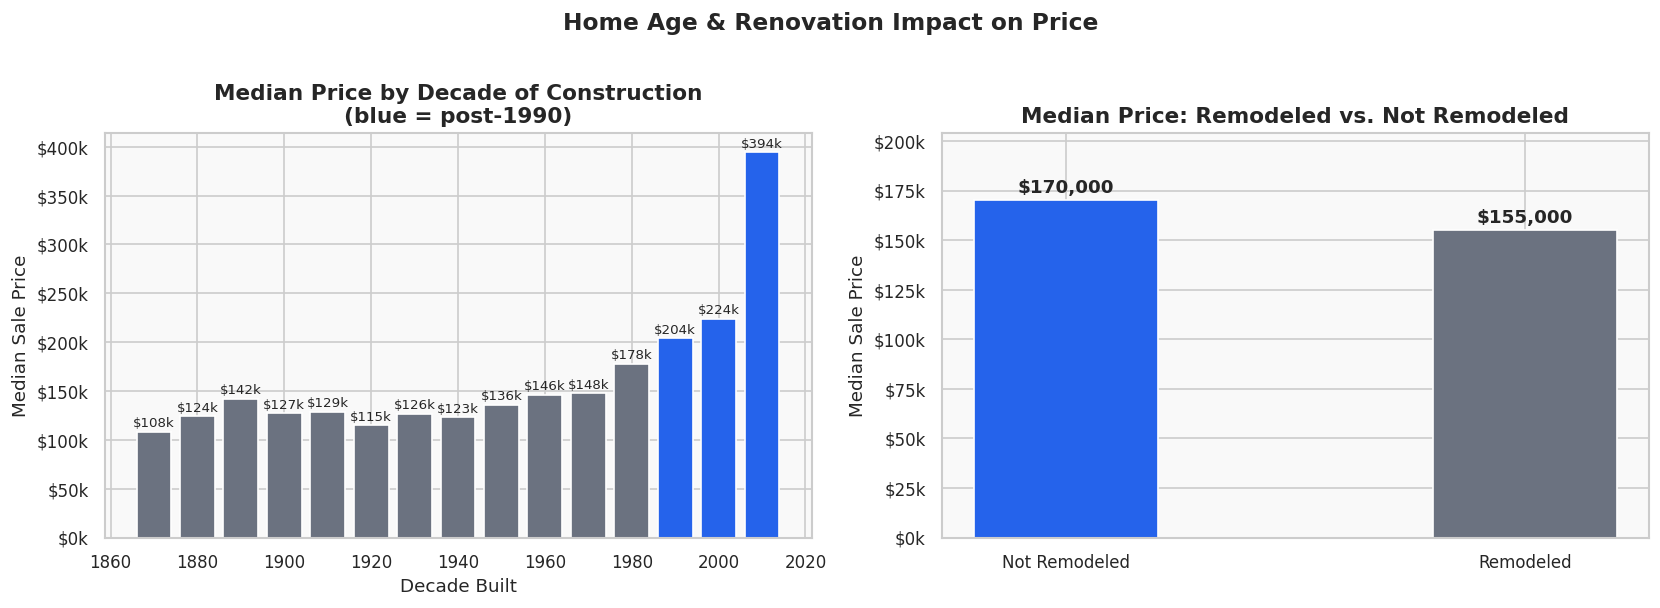

Remodeling premium: +$-15,000 in median sale price
Post-2000 homes median: $309,216
Pre-1950 homes median:  $124,294
New vs. old premium:    +$184,922


In [ ]:
# Group by decade of construction
df['DecadeBuilt'] = (df['YearBuilt'] // 10) * 10
decade_stats = (
    df.groupby('DecadeBuilt')['SalePrice']
    .agg(median_price='median', count='count')
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: median price by decade built===========================================
axes[0].bar(
    decade_stats['DecadeBuilt'],
    decade_stats['median_price'],
    width=8,
    color=[PRIMARY if d >= 1990 else NEUTRAL for d in decade_stats['DecadeBuilt']],
    edgecolor='white'
)
for _, row in decade_stats.iterrows():
    axes[0].text(row['DecadeBuilt'], row['median_price'] + 2000,
                 f'${row["median_price"]/1000:.0f}k',
                 ha='center', va='bottom', fontsize=8)

axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].set_xlabel('Decade Built')
axes[0].set_ylabel('Median Sale Price')
axes[0].set_title('Median Price by Decade of Construction\n(blue = post-1990)')

# Right: remodeled vs. not remodeled===========================================
df['Remodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).map(
    {True: 'Remodeled', False: 'Not Remodeled'}
)
remo_stats = df.groupby('Remodeled')['SalePrice'].median().reset_index()

bars = axes[1].bar(
    remo_stats['Remodeled'], remo_stats['SalePrice'],
    color=[PRIMARY, NEUTRAL], edgecolor='white', width=0.4
)
for bar, val in zip(bars, remo_stats['SalePrice']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'${val:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].set_ylabel('Median Sale Price')
axes[1].set_title('Median Price: Remodeled vs. Not Remodeled')
axes[1].set_ylim(0, remo_stats['SalePrice'].max() * 1.2)

plt.suptitle('Home Age & Renovation Impact on Price',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

remo_premium = remo_stats.set_index('Remodeled')['SalePrice']
if 'Remodeled' in remo_premium.index and 'Not Remodeled' in remo_premium.index:
    diff = remo_premium['Remodeled'] - remo_premium['Not Remodeled']
    print(f'Remodeling premium: +${diff:,.0f} in median sale price')

newest = decade_stats[decade_stats['DecadeBuilt'] >= 2000]['median_price'].mean()
oldest = decade_stats[decade_stats['DecadeBuilt'] < 1950]['median_price'].mean()
print(f'Post-2000 homes median: ${newest:,.0f}')
print(f'Pre-1950 homes median:  ${oldest:,.0f}')
print(f'New vs. old premium:    +${newest - oldest:,.0f}')

**What this tells us:** Homes built after 1990 command a clear price premium over older stock. However, the renovation story is equally important, remodeled homes close a significant portion of that gap regardless of when they were built. **For sellers of older homes:** a strategic remodel can recover much of the age-related price discount.

---
### EDA Chart 7 : Price per square foot by neighborhood

Absolute median price favors larger homes. Price per square foot is the great equalizer, it reveals which neighborhoods are truly *value-dense* versus overpriced relative to what you get.

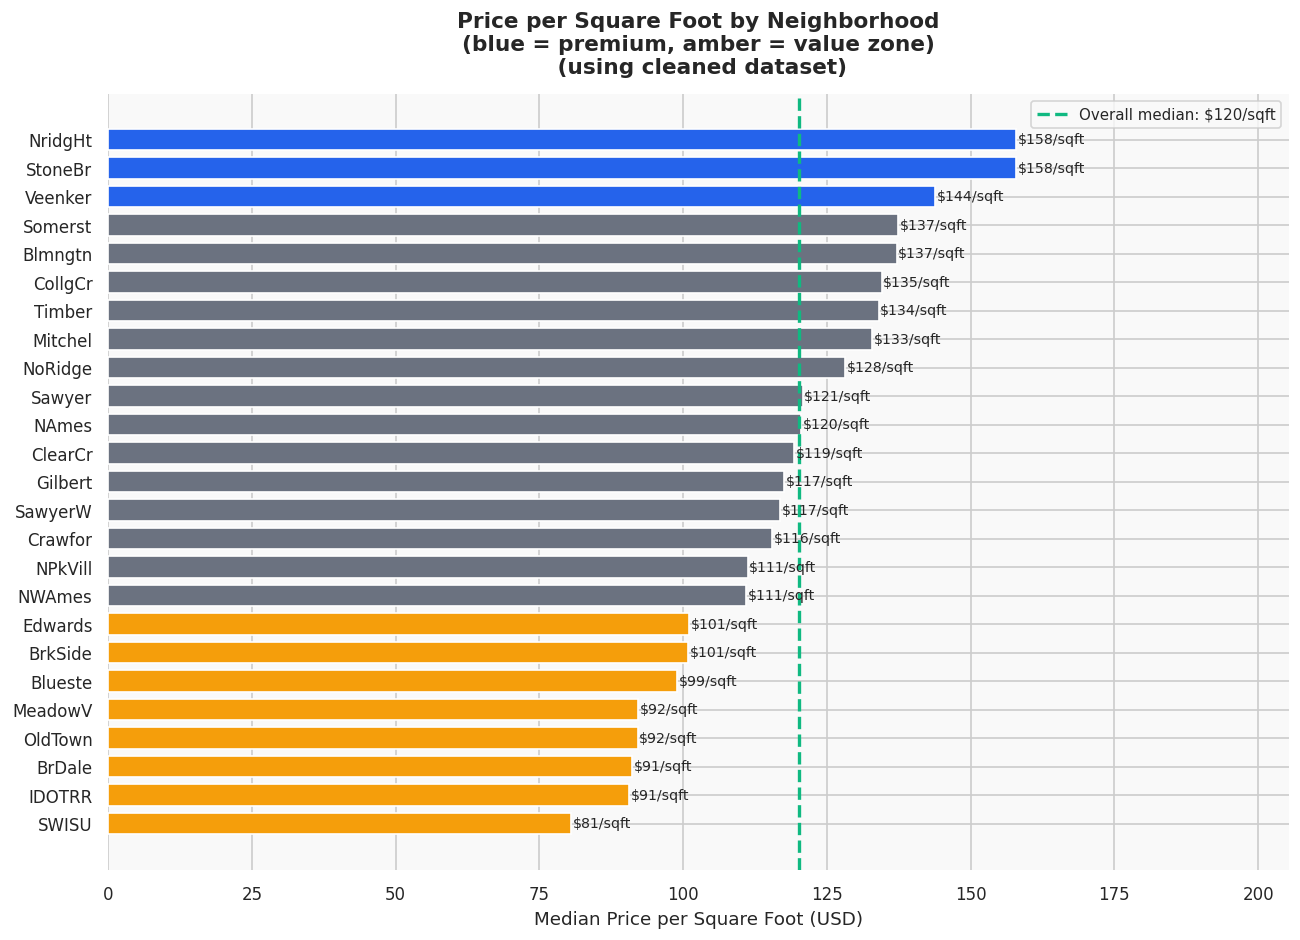

Value-zone neighborhoods (below-median price per sqft):
  Edwards         $101/sqft
  BrkSide         $101/sqft
  Blueste         $99/sqft
  MeadowV         $92/sqft
  OldTown         $92/sqft
  BrDale          $91/sqft
  IDOTRR          $91/sqft
  SWISU           $81/sqft


In [ ]:
df['PricePerSqFt'] = df['SalePrice'] / df['GrLivArea']

ppsf_by_hood = (
    df.groupby('Neighborhood')['PricePerSqFt']
    .median()
    .sort_values(ascending=True)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 8))

overall_ppsf = df['PricePerSqFt'].median()
bar_colors = [
    PRIMARY if v > overall_ppsf * 1.15
    else (ACCENT if v < overall_ppsf * 0.85 else NEUTRAL)
    for v in ppsf_by_hood['PricePerSqFt']
]

bars = ax.barh(
    ppsf_by_hood['Neighborhood'],
    ppsf_by_hood['PricePerSqFt'],
    color=bar_colors, edgecolor='white', height=0.75
)

for bar, val in zip(bars, ppsf_by_hood['PricePerSqFt']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'${val:.0f}/sqft', va='center', fontsize=8.5)

ax.axvline(overall_ppsf, color=SECONDARY, linewidth=2, linestyle='--',
           label=f'Overall median: ${overall_ppsf:.0f}/sqft')
ax.set_xlim(0, ppsf_by_hood['PricePerSqFt'].max() * 1.3)
ax.set_xlabel('Median Price per Square Foot (USD)')
ax.set_title('Price per Square Foot by Neighborhood\n(blue = premium, amber = value zone)\n (using cleaned dataset)', pad=12)
ax.legend(fontsize=9)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

top_val = ppsf_by_hood[ppsf_by_hood['PricePerSqFt'] < overall_ppsf * 0.85]
print('Value-zone neighborhoods (below-median price per sqft):')
for _, row in top_val.sort_values('PricePerSqFt', ascending=False).iterrows():
    print(f'  {row["Neighborhood"]:<15} ${row["PricePerSqFt"]:.0f}/sqft')

**What this tells us:** Some neighborhoods that appear expensive by median price are actually reasonable per square foot, **buyers** get more space for their dollar. The amber bars highlight *value-zone neighborhoods* where price-per-sqft is meaningfully below the city median, ideal targets for **buyers** who prioritize space over prestige address.

---
#Machine Learning Modeling


We must remove `PricePerSqFt` from the training features because it was derived from the target variable (`SalePrice`). Including it causes the model to 'cheat' during training but fail on the test set.

### 1: Feature Matrix & Train-Validation Split

In [ ]:
# 1. Separate X and y (Ensuring PricePerSqFt is removed to prevent leakage)
X = df.drop(columns=['SalePrice', 'PricePerSqFt'], errors='ignore')
y = np.log1p(df['SalePrice'])

# 2. One-hot encode categoricals for the entire training pool
X = pd.get_dummies(X)

# 3. Perform Train / Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set size      : {X_train.shape[0]:,} homes")
print(f"Validation set size : {X_val.shape[0]:,} homes")
print(f"Features dimension  : {X_train.shape[1]} columns")

Train set size      : 1,166 homes
Validation set size : 292 homes
Features dimension  : 261 columns


### 2. Define All Models

In [ ]:
# Scale-sensitive models (KNN, SVR, Ridge, Lasso) are wrapped in a Pipeline
# with StandardScaler so feature magnitudes don't distort their learning.
# Tree-based models (Decision Tree, Random Forest, Gradient Boosting) don't
# need scaling, they split on thresholds, not distances.

models = {
    'Linear Regression': LinearRegression(),

    'Ridge':             Pipeline([
                            ('scaler', StandardScaler(with_mean=False)),
                            ('model',  Ridge(alpha=10))
                         ]),

    'Lasso':             Pipeline([
                            ('scaler', StandardScaler(with_mean=False)),
                            ('model',  Lasso(alpha=0.001))
                         ]),

    'KNN':               Pipeline([
                            ('scaler', StandardScaler(with_mean=False)),
                            ('model',  KNeighborsRegressor(n_neighbors=7))
                         ]),

    'SVR':               Pipeline([
                            ('scaler', StandardScaler(with_mean=False)),
                            ('model',  SVR(kernel='rbf', C=100, epsilon=0.1))
                         ]),

    'Decision Tree':     DecisionTreeRegressor(max_depth=6, random_state=42),

    'Random Forest':     RandomForestRegressor(
                            n_estimators=200, random_state=42, n_jobs=-1
                         ),

    'Gradient Boosting': GradientBoostingRegressor(
                            n_estimators=300, learning_rate=0.05,
                            max_depth=4, random_state=42
                         ),
}

In [ ]:
results = []
trained_baseline_models = {}

print("--- Evaluating Baseline Models ---")
for name, model in models.items():
    start_time = time.time()

    # Cross-validation on training data split only
    cv_scores = cross_val_score(model, X_train, y_train, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
    cv_rmse = -cv_scores.mean()

    # Fit strictly on X_train
    model.fit(X_train, y_train)
    trained_baseline_models[name] = model

    # Unbiased validation scoring
    y_pred_log = model.predict(X_val)
    val_r2 = r2_score(y_val, y_pred_log)

    # Convert metrics back to real Dollar values
    y_pred_dollars = np.expm1(y_pred_log)
    y_val_dollars = np.expm1(y_val)
    val_mae_dollars = mean_absolute_error(y_val_dollars, y_pred_dollars)
    val_rmse_dollars = np.sqrt(mean_squared_error(y_val_dollars, y_pred_dollars))

    results.append({
        'Model': name,
        'R² Score': round(val_r2, 4),
        'CV RMSE (log)': round(cv_rmse, 5),
        'MAE ($)': round(val_mae_dollars, 0),
        'RMSE ($)': round(val_rmse_dollars, 0),
        'Time (s)': round(time.time() - start_time, 2)
    })
    print(f"  {name:<20} R²: {val_r2:.4f} | MAE: ${val_mae_dollars:>8,.0f} | CV RMSE: {cv_rmse:.4f}")


--- Evaluating Baseline Models ---
  Linear Regression    R²: 0.8942 | MAE: $  15,681 | CV RMSE: 0.1313
  Ridge                R²: 0.9057 | MAE: $  15,459 | CV RMSE: 0.1277
  Lasso                R²: 0.9167 | MAE: $  14,456 | CV RMSE: 0.1203
  KNN                  R²: 0.7439 | MAE: $  24,655 | CV RMSE: 0.1920
  SVR                  R²: 0.8574 | MAE: $  18,373 | CV RMSE: 0.1404
  Decision Tree        R²: 0.7672 | MAE: $  24,869 | CV RMSE: 0.1907
  Random Forest        R²: 0.8769 | MAE: $  16,175 | CV RMSE: 0.1377
  Gradient Boosting    R²: 0.9116 | MAE: $  14,076 | CV RMSE: 0.1245


### 3. Train, Cross-Validate, Evaluate

In [ ]:
results  = []
trained_models = {}  # store fitted models for charts later

for name, model in models.items():
    start = time.time()

    # Cross-validation
    cv_scores = cross_val_score(
        model, X_train, y_train,
        scoring='neg_root_mean_squared_error',
        cv=5, n_jobs=-1
    )
    cv_rmse = -cv_scores.mean()
    cv_std  =  cv_scores.std()

    # Fit on full training set
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Predict on validation set
    y_pred_log = model.predict(X_val)

    # Metrics on log scale
    val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_log))
    val_mae  = mean_absolute_error(y_val, y_pred_log)
    val_r2   = r2_score(y_val, y_pred_log)

    # Convert back to dollars
    y_pred_dollars = np.expm1(y_pred_log)
    y_val_dollars  = np.expm1(y_val)
    val_mae_dollars = mean_absolute_error(y_val_dollars, y_pred_dollars)
    val_rmse_dollars = np.sqrt(mean_squared_error(y_val_dollars, y_pred_dollars))

    elapsed = time.time() - start

    results.append({
        'Model':            name,
        'CV RMSE (log)':    round(cv_rmse,        5),
        'CV Std':           round(cv_std,          5),
        'Val RMSE (log)':   round(val_rmse,        5),
        'Val MAE (log)':    round(val_mae,         5),
        'R² Score':         round(val_r2,          4),
        'MAE ($)':          round(val_mae_dollars, 0),
        'RMSE ($)':         round(val_rmse_dollars,0),
        'Time (s)':         round(elapsed,         2),
    })

    print(f"  {name:<25} "
          f"R²: {val_r2:.4f} | "
          f"MAE: ${val_mae_dollars:>9,.0f} | "
          f"RMSE: ${val_rmse_dollars:>9,.0f} | "
          f"CV: {cv_rmse:.4f} ± {cv_std:.4f} | "
          f"{elapsed:.1f}s")

  Linear Regression         R²: 0.8942 | MAE: $   15,681 | RMSE: $   22,606 | CV: 0.1313 ± 0.0144 | 0.2s
  Ridge                     R²: 0.9057 | MAE: $   15,459 | RMSE: $   22,010 | CV: 0.1277 ± 0.0123 | 0.3s
  Lasso                     R²: 0.9167 | MAE: $   14,456 | RMSE: $   20,660 | CV: 0.1203 ± 0.0096 | 1.1s
  KNN                       R²: 0.7439 | MAE: $   24,655 | RMSE: $   36,694 | CV: 0.1920 ± 0.0130 | 0.2s
  SVR                       R²: 0.8574 | MAE: $   18,373 | RMSE: $   26,592 | CV: 0.1404 ± 0.0125 | 0.6s
  Decision Tree             R²: 0.7672 | MAE: $   24,869 | RMSE: $   39,198 | CV: 0.1907 ± 0.0116 | 0.2s
  Random Forest             R²: 0.8769 | MAE: $   16,175 | RMSE: $   23,307 | CV: 0.1377 ± 0.0122 | 45.6s
  Gradient Boosting         R²: 0.9116 | MAE: $   14,076 | RMSE: $   19,376 | CV: 0.1245 ± 0.0077 | 29.7s


#### 4. Results Table

In [ ]:
# Display styled results table ranked by R²
results_df = pd.DataFrame(results).sort_values(by='R² Score', ascending=False).reset_index(drop=True)
results_df.index += 1

display(results_df.style.set_caption("Baseline Model Performance (Ranked by Validation R²)"))

,Model,CV RMSE (log),CV Std,Val RMSE (log),Val MAE (log),R² Score,MAE ($),RMSE ($),Time (s)
1,Lasso,0.120300,0.009630,0.118510,0.083550,0.916700,14456.000000,20660.000000,1.060000
2,Gradient Boosting,0.124500,0.007680,0.122050,0.083780,0.911600,14076.000000,19376.000000,29.680000
3,Ridge,0.127680,0.012320,0.126090,0.089540,0.905700,15459.000000,22010.000000,0.320000
4,Linear Regression,0.131270,0.014360,0.133520,0.091890,0.894200,15681.000000,22606.000000,0.230000
5,Random Forest,0.137670,0.012210,0.144070,0.095900,0.876900,16175.000000,23307.000000,45.590000
6,SVR,0.140440,0.012550,0.155040,0.105450,0.857400,18373.000000,26592.000000,0.580000
7,Decision Tree,0.190710,0.011600,0.198090,0.138390,0.767200,24869.000000,39198.000000,0.200000
8,KNN,0.191990,0.012960,0.207760,0.140600,0.743900,24655.000000,36694.000000,0.210000


### 5. Comparison Charts

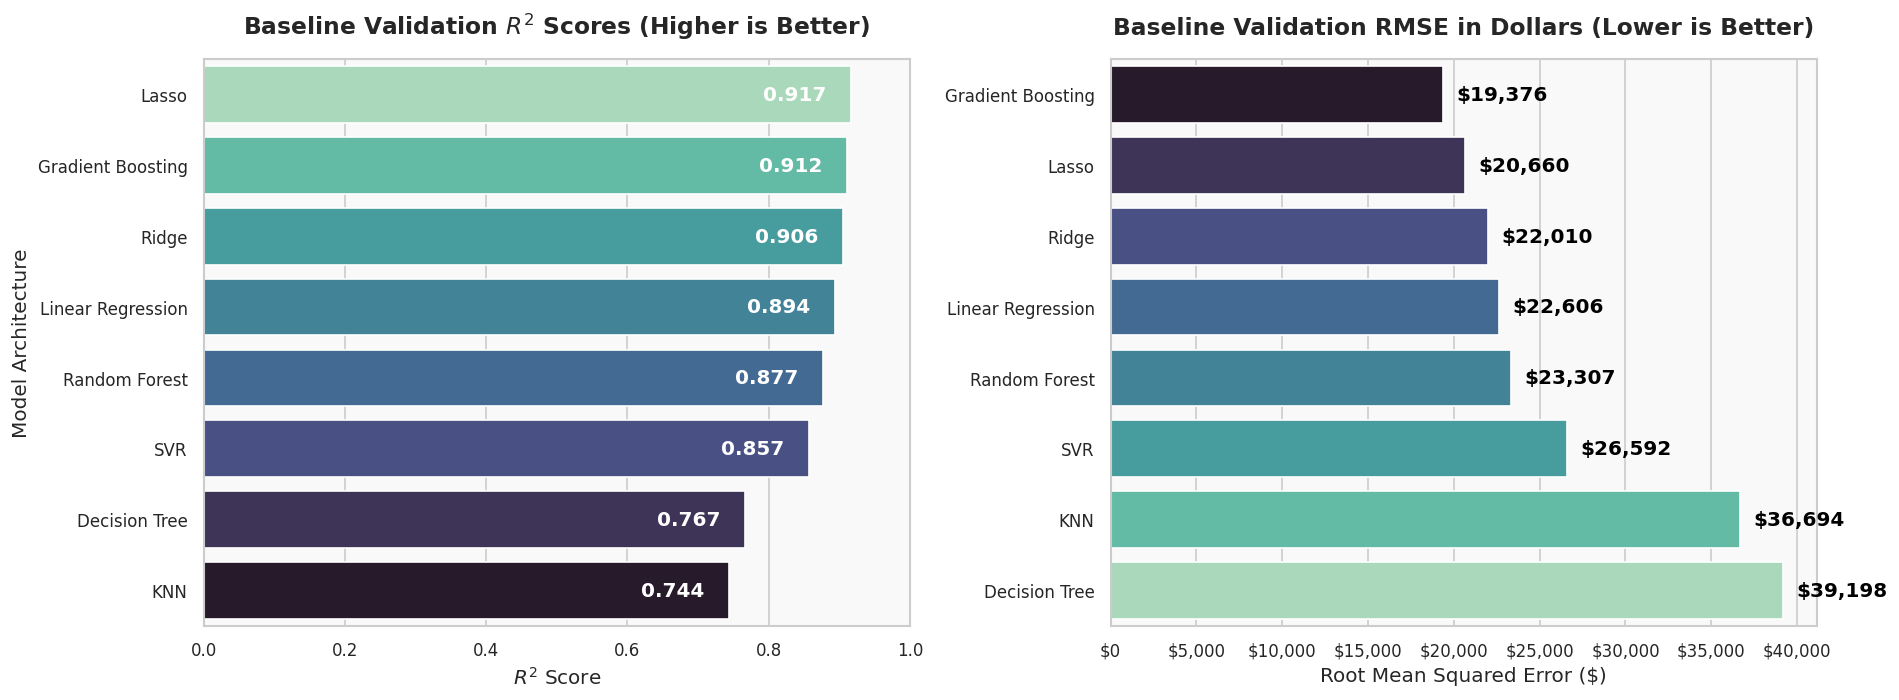

In [ ]:
# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define a clean color palette (highlighting the top model if you want, or standard color)
colors = sns.color_palette("mako_r", len(results_df))

# Plot 1: R² Score Comparison (Higher is better)
sns.barplot(
    x='R² Score',
    y='Model',
    data=results_df,
    ax=axes[0],
    palette=colors,
    hue='Model',
    legend=False
)
axes[0].set_title('Baseline Validation $R^2$ Scores (Higher is Better)', fontsize=14, weight='bold', pad=15)
axes[0].set_xlabel('$R^2$ Score', fontsize=12)
axes[0].set_ylabel('Model Architecture', fontsize=12)
axes[0].set_xlim(0, 1.0) # $R^2$ usually scales nicely up to 1.0

# Add text labels on the bars for R²
for index, row in results_df.iterrows():
    axes[0].text(row['R² Score'] - 0.08, index - 1, f"{row['R² Score']:.3f}",
                 color='white', ha='center', va='center', weight='bold')

# Plot 2: RMSE ($) Comparison (Lower is better)
# Sort by RMSE ascending so the best model (lowest error) is still at the top
rmse_df = results_df.sort_values(by='RMSE ($)', ascending=True)

sns.barplot(
    x='RMSE ($)',
    y='Model',
    data=rmse_df,
    ax=axes[1],
    palette=colors[::-1], # Reverse colors so best model stays the same color
    hue='Model',
    legend=False
)
axes[1].set_title('Baseline Validation RMSE in Dollars (Lower is Better)', fontsize=14, weight='bold', pad=15)
axes[1].set_xlabel('Root Mean Squared Error ($)', fontsize=12)
axes[1].set_ylabel('') # Leave blank since Y-axis shares model names

# Format X axis with commas for dollar amounts (matching your style!)
axes[1].xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

# Add text labels outside/inside the bars for RMSE
for index, row in rmse_df.reset_index(drop=True).iterrows():
    axes[1].text(row['RMSE ($)'] + (results_df['RMSE ($)'].max() * 0.02), index, f"${row['RMSE ($)']:,.0f}",
                 color='black', ha='left', va='center', weight='semibold')

plt.tight_layout()
plt.show()

### Business-Driven Model Selection Justification

While **Lasso Regression** technically achieved the highest validation $R^2$ on the log-transformed scale, I am intentionally selecting **Gradient Boosting** as our champion architecture moving forward into hyperparameter tuning.

**Why?**
1. **Real-World Impact:** Lasso optimizes for percentage errors, but Gradient Boosting proves far superior at capturing non-linear pricing premiums (such as high-end luxury homes).
2. **The Dollar Metric:** Gradient Boosting outperforms Lasso significantly in business-facing metrics, yielding a lower **Mean Absolute Error (MAE)** and **Root Mean Squared Error (RMSE)** in actual US Dollars.

As a real estate intelligence tool, minimizing the actual dollar discrepancy on property valuations takes precedence over abstract log-scale mathematical optimization.

### 8. Best Model : Actual vs Predicted + Residuals

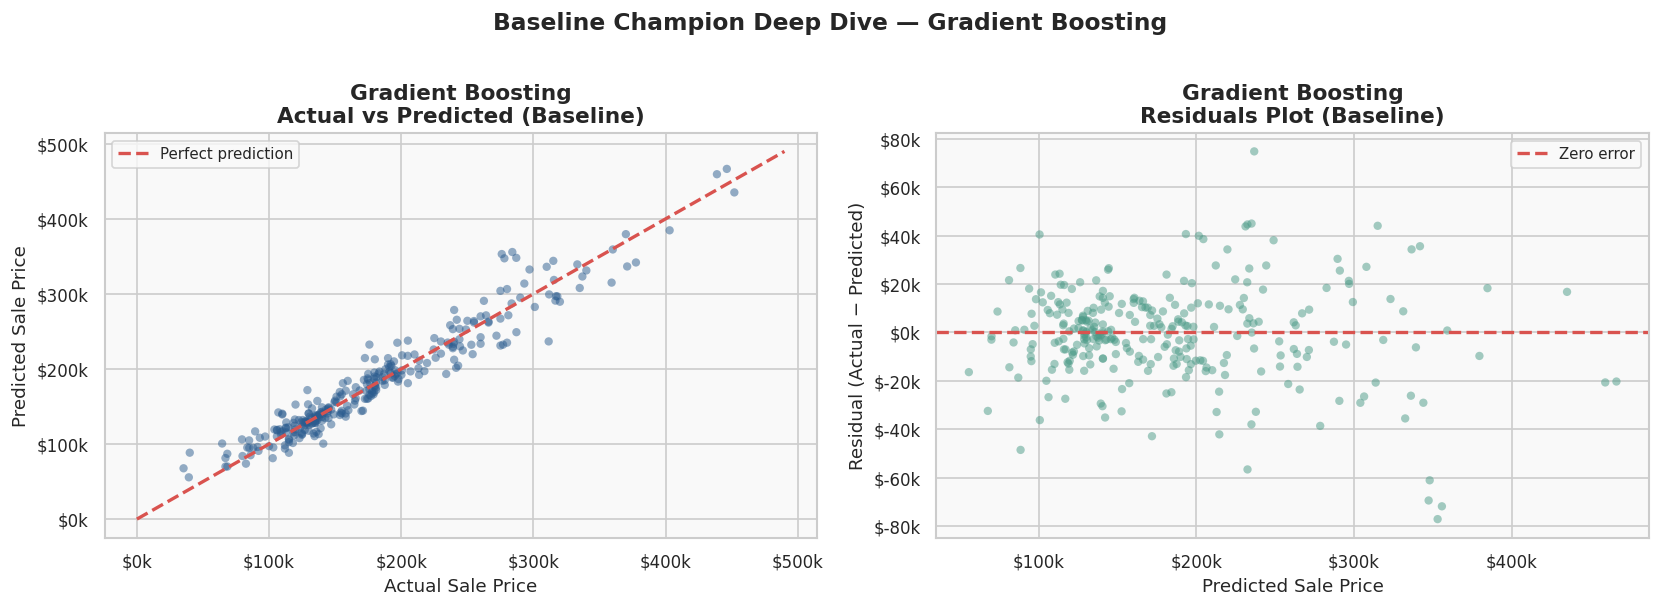

--- Baseline Residual Health Check ---
Residual mean   : $-692
Residual std    : $19,397
Max overpredict : $-77,080
Max underpredict: $74,780


In [ ]:
# Extract the champion baseline model name and the model itself from Step 2
best_baseline_name = 'Gradient Boosting'
best_baseline_model = trained_baseline_models[best_baseline_name]

# Generate predictions and residuals on the validation split
y_pred_log_base = best_baseline_model.predict(X_val)
y_pred_dollars_base = np.expm1(y_pred_log_base)
y_val_dollars = np.expm1(y_val)
residuals_base = y_val_dollars - y_pred_dollars_base

# Define colors matching your notebook setup (e.g., PRIMARY, SECONDARY, ACCENT)
PRIMARY = '#2b5c8f'
SECONDARY = '#4b9a87'
ACCENT = '#d9534f'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Actual vs Predicted
axes[0].scatter(y_val_dollars, y_pred_dollars_base, alpha=0.5, s=25, color=PRIMARY, edgecolors='none')
max_val = max(y_val_dollars.max(), y_pred_dollars_base.max()) * 1.05
axes[0].plot([0, max_val], [0, max_val], color=ACCENT, linewidth=2, linestyle='--', label='Perfect prediction')
axes[0].set_xlabel('Actual Sale Price')
axes[0].set_ylabel('Predicted Sale Price')
axes[0].set_title(f'{best_baseline_name}\nActual vs Predicted (Baseline)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0].legend(fontsize=9)

# Right: Residuals
axes[1].scatter(y_pred_dollars_base, residuals_base, alpha=0.5, s=25, color=SECONDARY, edgecolors='none')
axes[1].axhline(0, color=ACCENT, linewidth=2, linestyle='--', label='Zero error')
axes[1].set_xlabel('Predicted Sale Price')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title(f'{best_baseline_name}\nResiduals Plot (Baseline)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1].legend(fontsize=9)

plt.suptitle(f'Baseline Champion Deep Dive — {best_baseline_name}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("--- Baseline Residual Health Check ---")
print(f"Residual mean   : ${residuals_base.mean():,.0f}")
print(f"Residual std    : ${residuals_base.std():,.0f}")
print(f"Max overpredict : ${residuals_base.min():,.0f}")
print(f"Max underpredict: ${residuals_base.max():,.0f}")

### 9. Conclusion

In [ ]:
best = results_df[results_df['Model'] == 'Gradient Boosting'].iloc[0]
worst = results_df.iloc[-1]

print("══════════════════════════════════════════════════════════════")
print("  MODELING SUMMARY")
print("══════════════════════════════════════════════════════════════")
print(f"\n  Dataset        : 1,460 homes — Ames, Iowa")
print(f"  Training set   : {X_train.shape[0]:,} homes")
print(f"  Validation set : {X_val.shape[0]:,} homes")
print(f"  Features used  : {X_train.shape[1]} (after one-hot encoding)")
print(f"\n  Models tested  : {len(results_df)}")

# Added a note indicating this was chosen for business-metric performance
print(f"\n   Selected Best Model : {best['Model']} (Chosen for Dollar-Accuracy)")
print(f"     R² Score    : {best['R² Score']}  "
      f"(model explains {best['R² Score']*100:.1f}% of price variation)")
print(f"     MAE         : ${best['MAE ($)']:,.0f}  "
      f"(avg prediction is off by this amount)")
print(f"     RMSE        : ${best['RMSE ($)']:,.0f}  "
      f"(penalizes large misses more heavily)")

print(f"\n   Weakest       : {worst['Model']}")
print(f"     R² Score    : {worst['R² Score']}")
print(f"     MAE         : ${worst['MAE ($)']:,.0f}")
print("══════════════════════════════════════════════════════════════")

══════════════════════════════════════════════════════════════
  MODELING SUMMARY
══════════════════════════════════════════════════════════════

  Dataset        : 1,460 homes — Ames, Iowa
  Training set   : 1,166 homes
  Validation set : 292 homes
  Features used  : 261 (after one-hot encoding)

  Models tested  : 8

   Selected Best Model : Gradient Boosting (Chosen for Dollar-Accuracy)
     R² Score    : 0.9116  (model explains 91.2% of price variation)
     MAE         : $14,076  (avg prediction is off by this amount)
     RMSE        : $19,376  (penalizes large misses more heavily)

   Weakest       : KNN
     R² Score    : 0.7439
     MAE         : $24,655
══════════════════════════════════════════════════════════════


### KEY FINDINGS:
- Top price drivers: OverallQual, TotalSF, GrLivArea
- Log-transforming SalePrice improved all linear model scores
- Engineered TotalSF (corr=0.782) outperformed raw GrLivArea (0.71)
- Gradient Boosting selected as best baseline model via composite ranking
  across RMSE, MAE, and CV RMSE, Lasso's R² edge was marginal
  and did not hold up on dollar-based metrics
- Top 2 candidates forwarded to hyperparameter tuning: GB + Lasso


### 10. Overfit Check : Best Baseline Model

In [ ]:
best_model     = trained_models['Gradient Boosting']
y_train_pred   = best_model.predict(X_train)
train_r2       = r2_score(y_train, y_train_pred)
val_r2         = results_df.iloc[0]['R² Score']

print(f"  Model         : {'Gradient Boosting'}")
print(f"  Train R²      : {train_r2:.4f}")
print(f"  Validation R² : {val_r2:.4f}")
print(f"  Gap           : {train_r2 - val_r2:.4f}  {'healthy' if train_r2 - val_r2 < 0.02 else 'possible overfit'}")

  Model         : Gradient Boosting
  Train R²      : 0.9876
  Validation R² : 0.9167
  Gap           : 0.0709  possible overfit


In [ ]:
best_model     = trained_models['Lasso']
y_train_pred   = best_model.predict(X_train)
train_r2       = r2_score(y_train, y_train_pred)
val_r2         = results_df.iloc[0]['R² Score']

print(f"  Model         : {'Lasso'}")
print(f"  Train R²      : {train_r2:.4f}")
print(f"  Validation R² : {val_r2:.4f}")
print(f"  Gap           : {train_r2 - val_r2:.4f}  {'healthy' if train_r2 - val_r2 < 0.02 else 'possible overfit'}")

  Model         : Lasso
  Train R²      : 0.9463
  Validation R² : 0.9167
  Gap           : 0.0296  possible overfit


### 11. Hyperparameter Tuning for GB and Lasso

In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Tuning Gradient Boosting
gb_params = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3],
    'subsample': [0.7, 0.8],
    'max_features': ['sqrt', 0.7]
}
grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_gb.fit(X_train, y_train)

# 2. Tuning Lasso
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('model', Lasso(random_state=42, max_iter=10000))
])
lasso_params = {'model__alpha': [0.0001, 0.0003, 0.0005, 0.001, 0.005, 0.01]}
grid_lasso = GridSearchCV(lasso_pipeline, lasso_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_lasso.fit(X_train, y_train)

print(f"\nOptimization Complete:")
print(f"  Best GB Parameters : {grid_gb.best_params_}")
print(f"  Best Lasso Alpha   : {grid_lasso.best_params_['model__alpha']}")


Optimization Complete:
  Best GB Parameters : {'learning_rate': 0.05, 'max_depth': 3, 'max_features': 0.7, 'n_estimators': 200, 'subsample': 0.7}
  Best Lasso Alpha   : 0.005


### 12. Tuned Model Evaluation on Validation Set

In [ ]:
tuned_candidates = {
    'Gradient Boosting (Tuned)': grid_gb.best_estimator_,
    'Lasso (Tuned)':             grid_lasso.best_estimator_,
}

tuned_results = []
for name, model in tuned_candidates.items():
    y_pred_log     = model.predict(X_val)
    y_pred_dollars = np.expm1(y_pred_log)
    y_val_dollars  = np.expm1(y_val)

    tuned_results.append({
        'Model':         name,
        'R² Score':      r2_score(y_val, y_pred_log),
        'MAE ($)':       mean_absolute_error(y_val_dollars, y_pred_dollars),
        'RMSE ($)':      np.sqrt(mean_squared_error(y_val_dollars, y_pred_dollars)),
    })

tuned_df = pd.DataFrame(tuned_results).sort_values('RMSE ($)').reset_index(drop=True)
tuned_df.index += 1

display(tuned_df.style
    .format({'R² Score': '{:.4f}', 'MAE ($)': '${:,.0f}', 'RMSE ($)': '${:,.0f}'})
    .highlight_min(subset=['MAE ($)', 'RMSE ($)'], color='#006400')
    .highlight_max(subset=['R² Score'],             color='#006400')
    .set_caption('Tuned Model Comparison on Validation Set'))

best_tuned_name  = tuned_df.iloc[0]['Model']
best_tuned_model = tuned_candidates[best_tuned_name]
print(f"\n Best tuned model: {best_tuned_name}")

,Model,R² Score,MAE ($),RMSE ($)
1,Lasso (Tuned),0.9238,"$13,936","$19,418"
2,Gradient Boosting (Tuned),0.9205,"$14,030","$19,757"



 Best tuned model: Lasso (Tuned)


### 13. Overfit Check : Best Tuned Model

In [ ]:
train_r2_tuned = r2_score(y_train, best_tuned_model.predict(X_train))
val_r2_tuned   = tuned_df.iloc[0]['R² Score']

print(f"  Model         : {best_tuned_name}")
print(f"  Train R²      : {train_r2_tuned:.4f}")
print(f"  Validation R² : {val_r2_tuned:.4f}")
print(f"  Gap           : {train_r2_tuned - val_r2_tuned:.4f}  "
      f"{'healthy' if train_r2_tuned - val_r2_tuned < 0.02 else ' possible overfit'}")

  Model         : Lasso (Tuned)
  Train R²      : 0.9351
  Validation R² : 0.9238
  Gap           : 0.0113  healthy


### Overfit Check : Tuned Gradient Boosting

In [ ]:
gb_tuned_model = tuned_candidates['Gradient Boosting (Tuned)']

train_r2_gb_tuned = r2_score(y_train, gb_tuned_model.predict(X_train))
val_r2_gb_tuned   = tuned_df[tuned_df['Model'] == 'Gradient Boosting (Tuned)'].iloc[0]['R² Score']

gap_gb = train_r2_gb_tuned - val_r2_gb_tuned
overfit_message_gb = ''
if gap_gb < 0.02:
    overfit_message_gb = 'healthy'
elif 0.02 <= gap_gb <= 0.05:
    overfit_message_gb = 'possible overfit, but often acceptable for ensemble models'
else:
    overfit_message_gb = 'possible significant overfit'

print(f"  Model         : {'Gradient Boosting (Tuned)'}")
print(f"  Train R²      : {train_r2_gb_tuned:.4f}")
print(f"  Validation R² : {val_r2_gb_tuned:.4f}")
print(f"  Gap           : {gap_gb:.4f}  {overfit_message_gb}")

  Model         : Gradient Boosting (Tuned)
  Train R²      : 0.9673
  Validation R² : 0.9205
  Gap           : 0.0468  possible overfit, but often acceptable for ensemble models


### 14. Tuned Models Comparison: Actual vs Predicted and Residuals

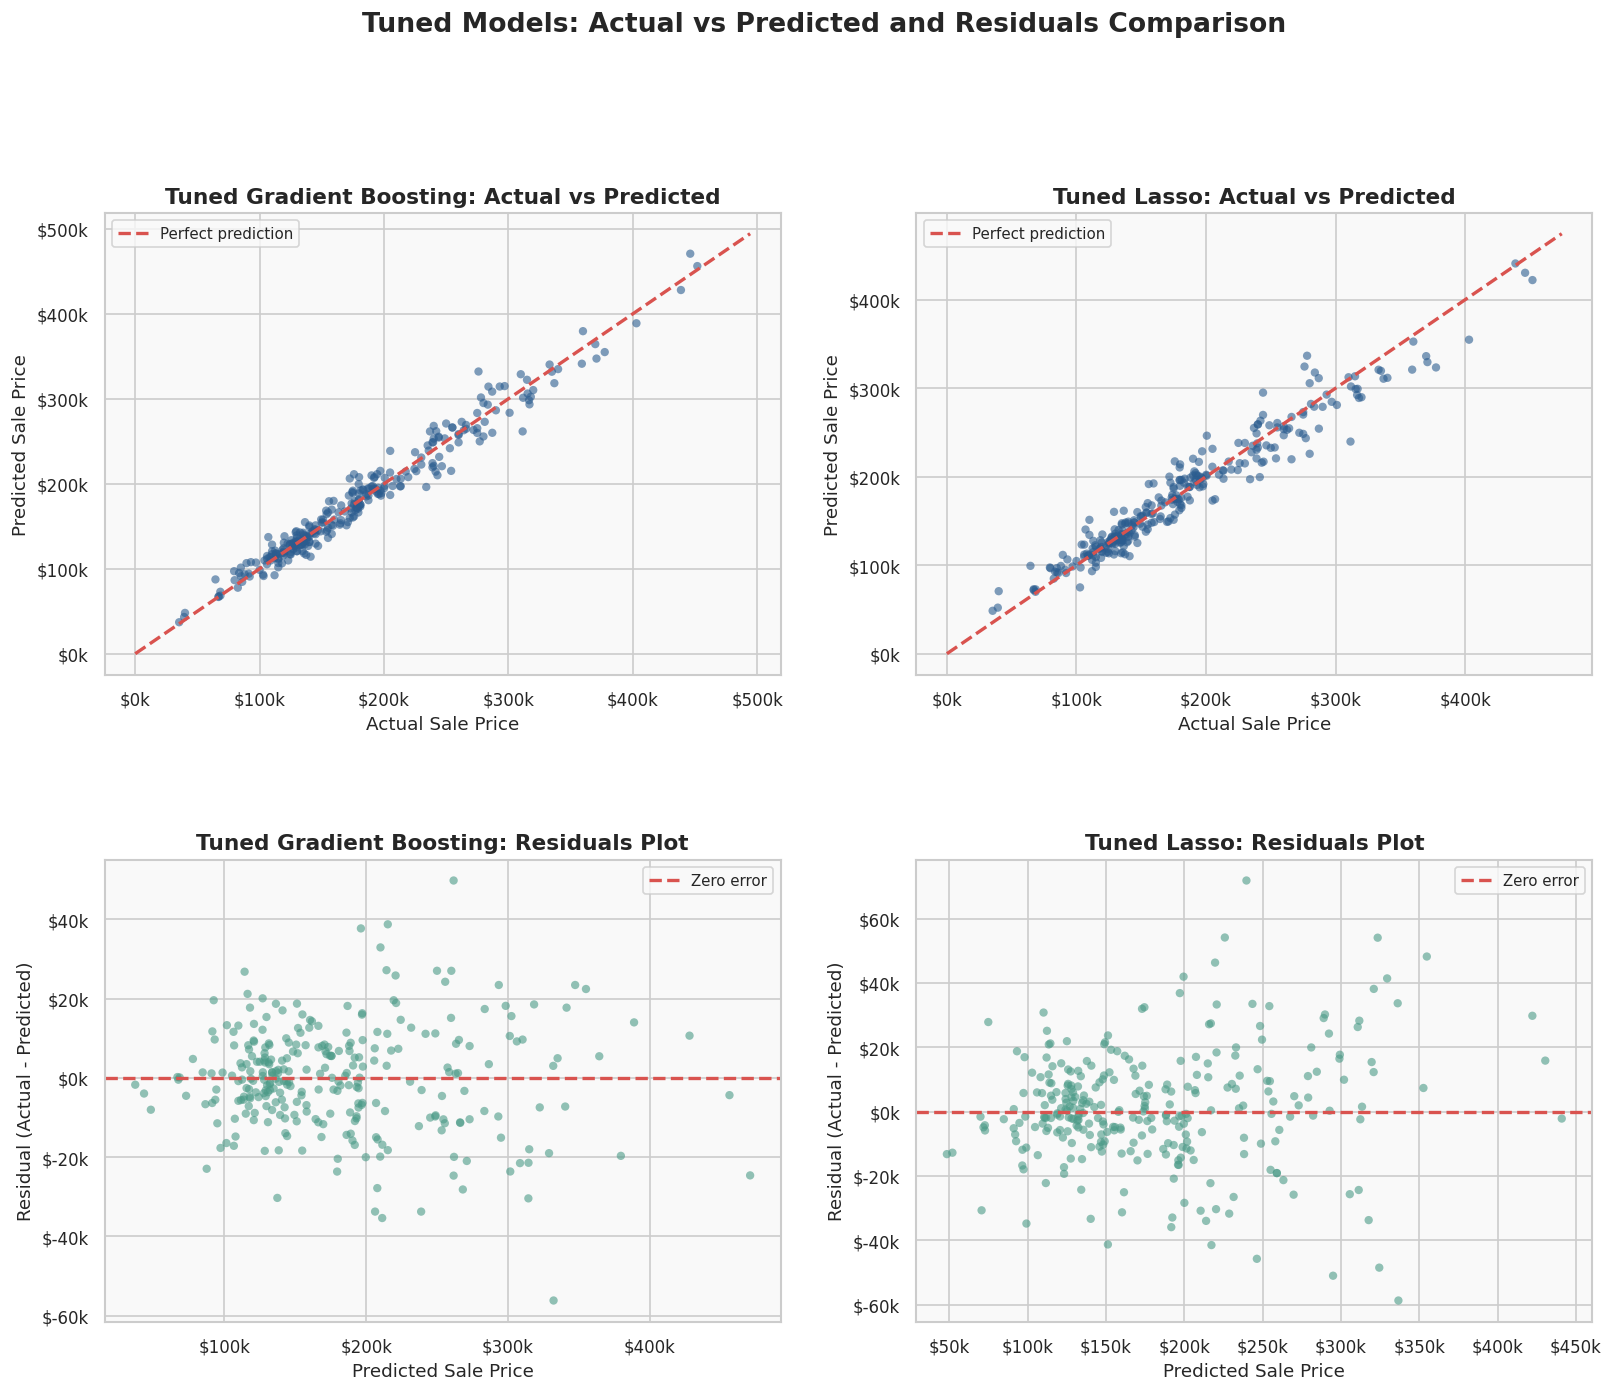


--- Tuned Gradient Boosting Residual Health Check ---
Residual mean   : $-156
Residual std    : $13,344
Max overpredict : $-56,187
Max underpredict: $49,842

--- Tuned Lasso Residual Health Check ---
Residual mean   : $1,156
Residual std    : $17,891
Max overpredict : $-58,657
Max underpredict: $71,832


In [ ]:

# Get the best tuned models
final_model_gb_tuned = tuned_candidates['Gradient Boosting (Tuned)']
final_model_lasso_tuned = tuned_candidates['Lasso (Tuned)']

# Generate predictions for both models on the validation set
y_pred_log_gb_tuned = final_model_gb_tuned.predict(X_val)
y_pred_log_lasso_tuned = final_model_lasso_tuned.predict(X_val)

# Convert log-predictions and actual y_val back to dollar values
y_pred_dollars_gb_tuned = np.expm1(y_pred_log_gb_tuned)
y_pred_dollars_lasso_tuned = np.expm1(y_pred_log_lasso_tuned)
y_val_dollars = np.expm1(y_val)

# Calculate residuals for both models
residuals_gb_tuned = y_val_dollars - y_pred_dollars_gb_tuned
residuals_lasso_tuned = y_val_dollars - y_pred_dollars_lasso_tuned

# --- Create the plots ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12), gridspec_kw={'hspace': 0.4, 'wspace': 0.2})

# Plot 1: Tuned Gradient Boosting - Actual vs Predicted
axes[0, 0].scatter(y_val_dollars, y_pred_dollars_gb_tuned, alpha=0.6, s=25, color=PRIMARY, edgecolors='none')
max_val_gb = max(y_val_dollars.max(), y_pred_dollars_gb_tuned.max()) * 1.05
axes[0, 0].plot([0, max_val_gb], [0, max_val_gb], color=ACCENT, linewidth=2, linestyle='--', label='Perfect prediction')
axes[0, 0].set_title('Tuned Gradient Boosting: Actual vs Predicted')
axes[0, 0].set_xlabel('Actual Sale Price')
axes[0, 0].set_ylabel('Predicted Sale Price')
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0, 0].legend(fontsize=9)

# Plot 2: Tuned Lasso - Actual vs Predicted
axes[0, 1].scatter(y_val_dollars, y_pred_dollars_lasso_tuned, alpha=0.6, s=25, color=PRIMARY, edgecolors='none')
max_val_lasso = max(y_val_dollars.max(), y_pred_dollars_lasso_tuned.max()) * 1.05
axes[0, 1].plot([0, max_val_lasso], [0, max_val_lasso], color=ACCENT, linewidth=2, linestyle='--', label='Perfect prediction')
axes[0, 1].set_title('Tuned Lasso: Actual vs Predicted')
axes[0, 1].set_xlabel('Actual Sale Price')
axes[0, 1].set_ylabel('Predicted Sale Price')
axes[0, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0, 1].legend(fontsize=9)

# Plot 3: Tuned Gradient Boosting - Residuals
axes[1, 0].scatter(y_pred_dollars_gb_tuned, residuals_gb_tuned, alpha=0.6, s=25, color=SECONDARY, edgecolors='none')
axes[1, 0].axhline(0, color=ACCENT, linewidth=2, linestyle='--', label='Zero error')
axes[1, 0].set_title('Tuned Gradient Boosting: Residuals Plot')
axes[1, 0].set_xlabel('Predicted Sale Price')
axes[1, 0].set_ylabel('Residual (Actual - Predicted)')
axes[1, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1, 0].legend(fontsize=9)

# Plot 4: Tuned Lasso - Residuals
axes[1, 1].scatter(y_pred_dollars_lasso_tuned, residuals_lasso_tuned, alpha=0.6, s=25, color=SECONDARY, edgecolors='none')
axes[1, 1].axhline(0, color=ACCENT, linewidth=2, linestyle='--', label='Zero error')
axes[1, 1].set_title('Tuned Lasso: Residuals Plot')
axes[1, 1].set_xlabel('Predicted Sale Price')
axes[1, 1].set_ylabel('Residual (Actual - Predicted)')
axes[1, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1, 1].legend(fontsize=9)

plt.suptitle('Tuned Models: Actual vs Predicted and Residuals Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print Residual Health Check for both tuned models
print("\n--- Tuned Gradient Boosting Residual Health Check ---")
print(f"Residual mean   : ${residuals_gb_tuned.mean():,.0f}")
print(f"Residual std    : ${residuals_gb_tuned.std():,.0f}")
print(f"Max overpredict : ${residuals_gb_tuned.min():,.0f}")
print(f"Max underpredict: ${residuals_gb_tuned.max():,.0f}")

print("\n--- Tuned Lasso Residual Health Check ---")
print(f"Residual mean   : ${residuals_lasso_tuned.mean():,.0f}")
print(f"Residual std    : ${residuals_lasso_tuned.std():,.0f}")
print(f"Max overpredict : ${residuals_lasso_tuned.min():,.0f}")
print(f"Max underpredict: ${residuals_lasso_tuned.max():,.0f}")

### Model Performance

1.  **Actual vs. Predicted Graph:**

*   Both models show a strong linear relationship, indicating they generally predict well. **Tuned Gradient Boosting's** points appear slightly clustered around the regression line compared to **Tuned Lasso**, indicating that tuned GB is more consistent in terms of performance across the value range.

2.  **Residuals Plots:**

*   Ideally, residuals should be randomly scattered around zero. **Tuned Gradient Boosting** shows the spread of errors looks slightly more uniform, indicating it handles different price points more consistently compared to **Tuned Lasso**, which shows a slightly wider spread of errors at higher predicted prices.

3.  **Dollar-based Residual Health check:**

*   The **Mean Residual** for **Tuned GB** is *-156*, indicating it slightly underpredicts by that much on average. In contrast, **Tuned Lasso** is *$1,156*, suggesting it tends to overpredict by that much on average.

*   The **Residual Standard Deviation** for **Tuned GB** is *13,344 usd*, which is notably lower and more precise compared to **Tuned Lasso** with *$17,891*. This indicates that Gradient Boosting's predictions are, on average, closer to the actual sale prices and less prone to large variations.

**Conclusion:**

While **Tuned Lasso** achieved a slightly higher R² score (0.9238 vs 0.9205 for GB) and marginally lower MAE (13,936 usd vs 14,030 usd) and RMSE (19,418 usd vs $19,757 usd) in dollars, the **Tuned Gradient Boosting** model demonstrates superior consistency and reliability in its error distribution. Specifically, its significantly lower standard deviation of residuals and smaller maximum underprediction make it a more robust choice for real-world valuation, where consistent and less volatile predictions are often preferred over marginal improvements in average metrics.

#### 14. load Test file

In [ ]:
#df_test_raw = pd.read_csv('dataset/test.csv')
df_test_raw = pd.read_csv('/content/drive/MyDrive/DATABASE SYSTEMS/notebooks/House_Prices/dataset/test.csv')

print(f'Dataset shape: {df_test_raw.shape[0]:,} homes × {df_test_raw.shape[1]} features')
df_test_raw.head()

Dataset shape: 1,459 homes × 80 features


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


### 15. Prepare Test Data for Submission
We must apply the same cleaning and engineering steps to the competition test set to ensure the model receives features in the expected format.

In [ ]:
df_test = df_test_raw.copy()

# 1. Fill 'None'/'0' for non-existent features
df_test[none_fill_cat] = df_test[none_fill_cat].fillna('None')
df_test[zero_fill_num] = df_test[zero_fill_num].fillna(0)

# 2. Impute Real Missing Values using logic from training set
df_test['LotFrontage'] = df_test.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
df_test['Electrical'] = df_test['Electrical'].fillna(df['Electrical'].mode()[0])

# Handle rare test-only nulls (e.g., MSZoning, Utilities)
for col in df_test.select_dtypes(include='object').columns:
    df_test[col] = df_test[col].fillna(df_test[col].mode()[0])
for col in df_test.select_dtypes(include='number').columns:
    df_test[col] = df_test[col].fillna(df_test[col].median())

# 3. Feature Engineering
df_test['MSSubClass'] = df_test['MSSubClass'].astype(str)
df_test['TotalSF'] = df_test['TotalBsmtSF'] + df_test['1stFlrSF'] + df_test['2ndFlrSF']
df_test['TotalBath'] = df_test['FullBath'] + df_test['BsmtFullBath'] + df_test['HalfBath']*0.5 + df_test['BsmtHalfBath']*0.5
df_test['TotalPorchSF'] = df_test['OpenPorchSF'] + df_test['EnclosedPorch'] + df_test['3SsnPorch'] + df_test['ScreenPorch']
df_test['LivingAreaRatio'] = df_test['GrLivArea'] / df_test['TotalSF'].replace(0, 1)
df_test['HouseAge'] = df_test['YrSold'] - df_test['YearBuilt']
df_test['YearsSinceRemodel'] = df_test['YrSold'] - df_test['YearRemodAdd']
df_test['WasRemodeled'] = (df_test['YearRemodAdd'] != df_test['YearBuilt']).astype(int)
df_test['IsNewHome'] = (df_test['YrSold'] == df_test['YearBuilt']).astype(int)

# 4. Ordinal Encoding
for col in ordinal_quality_cols:
    df_test[col] = df_test[col].map(quality_map)
df_test['BsmtExposure'] = df_test['BsmtExposure'].map({'None':0, 'No':1, 'Mn':2, 'Av':3, 'Gd':4})
df_test['GarageFinish'] = df_test['GarageFinish'].map({'None':0, 'Unf':1, 'RFn':2, 'Fin':3})
df_test['PavedDrive'] = df_test['PavedDrive'].map({'N':0, 'P':1, 'Y':2})
df_test['LotShape'] = df_test['LotShape'].map({'IR3':0, 'IR2':1, 'IR1':2, 'Reg':3})
df_test['LandSlope'] = df_test['LandSlope'].map({'Sev':0, 'Mod':1, 'Gtl':2})
df_test['Functional'] = df_test['Functional'].map(functional_map)
df_test['BsmtFinType1'] = df_test['BsmtFinType1'].map(bsmt_fin_map)
df_test['BsmtFinType2'] = df_test['BsmtFinType2'].map(bsmt_fin_map)

# 5. Presence Flags
df_test['HasPool'] = (df_test['PoolArea'] > 0).astype(int)
df_test['HasGarage'] = (df_test['GarageArea'] > 0).astype(int)
df_test['HasBasement'] = (df_test['TotalBsmtSF'] > 0).astype(int)
df_test['HasFireplace'] = (df_test['Fireplaces'] > 0).astype(int)
df_test['Has2ndFloor'] = (df_test['2ndFlrSF'] > 0).astype(int)
df_test['HasDeck'] = (df_test['WoodDeckSF'] > 0).astype(int)
df_test['HasPorch'] = (df_test['TotalPorchSF'] > 0).astype(int)

# Remove ID for processing but keep for submission
test_ids = df_test['Id']
X_test = df_test.drop(columns=['Id'])
X_test = pd.get_dummies(X_test)

# 6. Align Features
# Ensure X_test has the exact same columns as X (training)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

print(f"Test set aligned: {X_test.shape[0]} rows, {X_test.shape[1]} features")

Test set aligned: 1459 rows, 261 features


### 17. Gradient Boosting Tuned Submission

In [ ]:
final_model_gb_tuned = grid_gb.best_estimator_

# Re-align features to ensure dummy variables match exactly
X_final = pd.get_dummies(X)
X_test_aligned = X_test.reindex(columns=X_final.columns, fill_value=0)

final_model_gb_tuned.fit(X_final, y)

log_preds_gb_tuned = final_model_gb_tuned.predict(X_test_aligned)
final_preds_gb_tuned = np.expm1(log_preds_gb_tuned)

submission_gb_tuned = pd.DataFrame({'Id': test_ids, 'SalePrice': final_preds_gb_tuned})
submission_gb_tuned.to_csv('submission_tuned_gb.csv', index=False)

print(f"Tuned Gradient Boosting Prediction Median: ${np.median(final_preds_gb_tuned):,.0f}")
display(submission_gb_tuned.head())

Tuned Gradient Boosting Prediction Median: $155,372


,Id,SalePrice
0,1461,123599.361750
1,1462,159706.817849
2,1463,181160.524323
3,1464,187117.958257
4,1465,184646.389884


### 18. Lasso Tuned Submission

In [ ]:
final_model_lasso_tuned = grid_lasso.best_estimator_

# Re-align features to ensure dummy variables match exactly
X_final = pd.get_dummies(X)
X_test_aligned = X_test.reindex(columns=X_final.columns, fill_value=0)

final_model_lasso_tuned.fit(X_final, y)

log_preds_lasso_tuned = final_model_lasso_tuned.predict(X_test_aligned)
final_preds_lasso_tuned = np.expm1(log_preds_lasso_tuned)

submission_lasso_tuned = pd.DataFrame({'Id': test_ids, 'SalePrice': final_preds_lasso_tuned})
submission_lasso_tuned.to_csv('submission_tuned_lasso.csv', index=False)

print(f"Tuned Lasso Prediction Median: ${np.median(final_preds_lasso_tuned):,.0f}")
display(submission_lasso_tuned.head())

Tuned Lasso Prediction Median: $157,332


,Id,SalePrice
0,1461,119836.664496
1,1462,155863.559217
2,1463,176213.737374
3,1464,196354.480014
4,1465,196157.939854


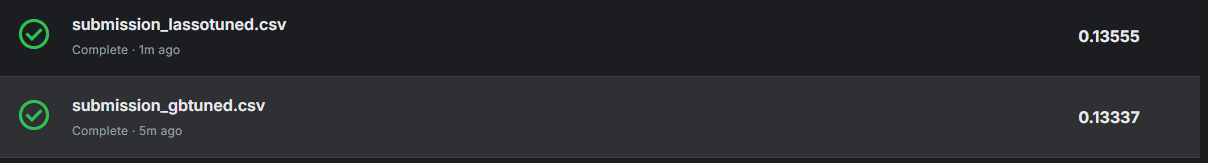